# Hyperparameter Tuning: Loop Closure Weight — Latent JacobianODE (Lorenz Full Obs)

This notebook performs a **Hydra grid sweep** over `loop_closure_weight` (and optionally
other hyperparameters like `fnn_weight`) for the **Latent JacobianODE** model in the
fully-observed 3D Lorenz setting (the same setup as
`Latent JacobianODE (Lorenz - full obs, identity test).ipynb`).

**Setting:**
- Input: Fully observed 3D Lorenz (all 3 coords, no noise)
- Encoder: LRU (SSM) without positional encoding — `(B, T, 3)` → `(B, T, 3)`
- Latent space: 3D (same dimension as the true system)
- Decoder: Pointwise MLP — `(B, T, 3)` → `(B, T, 3)`

**Workflow:**
1. Set hyperparameters matching the identity-test notebook
2. Configure `SWEEP_PARAMS` (Section 1) — use only `loop_closure_weight` for a 1D sweep, or add `fnn_weight` (etc.) for a grid sweep
3. Build the base config and generate data
4. Launch a Hydra `--multirun` sweep over the chosen parameters via SLURM
5. After training, query W&B to collect run IDs
6. Apply the physics-informed model selection criteria (C1/C2/C3) to pick the best params
7. Load and inspect the selected model

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf
import os
import subprocess
import torch
from torch.autograd.functional import jacobian as autograd_jacobian
from tqdm.auto import tqdm
import wandb


In [3]:
from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
    create_dataloaders,
    make_model,
    load_run,
    load_checkpoint,
)
from JacobianODE.jacobians.metrics import r2_score
from JacobianODE.jacobians.tuning import DEFAULT_LAMBDA_LOOP_VALUES, select_from_wandb_runs
from JacobianODE.jacobians.tuning.criteria import (
    compute_all_diagnostics,
    DiagnosticMetrics,
)
from JacobianODE.jacobians.tuning.selection import select_best_model

In [4]:
seed_everything(42)

42

## 1. Hyperparameters

All hyperparameters match the `Latent JacobianODE (Lorenz - full obs, identity test)` notebook
exactly. Use `SWEEP_PARAMS` below to choose which parameters to grid-sweep (e.g. `loop_closure_weight` alone, or in combination with `fnn_weight`).

In [5]:
# ----------------------------------------------------------------
# Paths and W&B settings
# ----------------------------------------------------------------
SAVE_DIR     = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs"
WANDB_ENTITY = "JacobianODE"

# W&B project — run_jacobians.py derives this automatically from the data type:
#   data_type=dysts + flow=Lorenz  →  'Lorenz__JacobianODE'
# The post-hoc evaluation queries this project to find the sweep runs.
# WANDB_PROJECT   = "Lorenz_3D_OBS0.01_FULL__JacobianODE"
WANDB_PROJECT   = "Lorenz_3D_OBS0.01_FULL_FNN__JacobianODE"
WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

# Optional: W&B group to separate different experiments within the same project.
# Set to a string (e.g. "loop_fnn_grid_2026", "sweep_v2") to group this sweep's runs.
# When set, sweep jobs log to this group and post-hoc evaluation filters by it.
# Set to None to log runs without a group.
WANDB_GROUP = None  # e.g. "loop_fnn_grid_2026-03" or "sweep_v2"

In [6]:
# ----------------------------------------------------------------
# Data hyperparameters
# ----------------------------------------------------------------
OBS_NOISE        = 0.01          # No noise: cleanest identity test
# OBS_NOISE        = 0.0
OBSERVED_INDICES = [0, 1, 2]     # Observe ALL three Lorenz dimensions
# OBSERVED_INDICES = [0]          # Observe only x
N_PERIODS        = 12            # Lorenz periods to simulate
PTS_PER_PERIOD   = 100           # Temporal resolution (dt ≈ 0.015)
NUM_ICS          = 32            # Independent initial conditions

# Known Lorenz Lyapunov exponents (σ=10, ρ=28, β=8/3)
TRUE_LYAPUNOV = [0.91, 0.0, -14.57]

In [7]:
# ----------------------------------------------------------------
# Encoder / Latent space hyperparameters
# ----------------------------------------------------------------
N_LATENT = 3      # Must equal the true system dimension
# N_LATENT = 6

# MLP encoder (pointwise: applies same MLP at every timestep)
MLP_HIDDEN_DIM = 256
MLP_N_LAYERS   = 3
MLP_DROPOUT    = 0.1

# Decoder MLP (pointwise: z_t → x̂_t)
DECODER_HIDDEN = 128
DECODER_LAYERS = 2

In [8]:
# ----------------------------------------------------------------
# Jacobian MLP hyperparameters
# ----------------------------------------------------------------
# JAC_HIDDEN_DIM = [512, 512, 512]
# JAC_NUM_LAYERS = 3
JAC_HIDDEN_DIM = [256, 1024, 2048, 2048]
JAC_NUM_LAYERS = 4
JAC_ACTIVATION = 'silu'

In [9]:
# ----------------------------------------------------------------
# Training hyperparameters
# ----------------------------------------------------------------
BATCH_SIZE               = 32
MAX_EPOCHS               = 150
LIMIT_TRAIN_BATCHES      = 200
LIMIT_VAL_BATCHES        = 50
ACCUMULATE_GRAD_BATCHES  = 1
# LEARNING_RATE            = 1e-4
LEARNING_RATE            = 5e-5
WEIGHT_DECAY             = 1e-4

ENCODER_WARMUP_EPOCHS    = 0
TRAJ_INIT_STEPS          = 15
# PREDICTION_STEPS         = 10
PREDICTION_STEPS         = 30
# PREDICTION_STEPS         = 100
RECONSTRUCTION_LOSS_WEIGHT = 1.0
LATENT_PREDICTION_LOSS_WEIGHT = 1.0
JAC_CONSISTENCY_WEIGHT   = 0.0
# JAC_CONSISTENCY_WEIGHT   = 1.0
# FNN_WEIGHT               = 0.0  # Weight for FNN latent-geometry regularizer (Gilpin NeurIPS 2020)
# FNN_WEIGHT               = 0.01

LEARN_R2_WEIGHT          = False  # Learn weight for R²-like loss group (homoscedastic UW)
LEARN_LOOP_CLOSURE_WEIGHT = False  # Learn weight for loop closure loss (homoscedastic UW)
LEARN_FNN_WEIGHT         = False  # Learn weight for FNN regularization (homoscedastic UW)
LEARN_JAC_CONS_WEIGHT    = False  # Learn weight for Jacobian consistency loss (homoscedastic UW)
LEARN_JAC_NORM_WEIGHT    = False  # Learn weight for Jacobian norm penalty (homoscedastic UW)
# LOG_VAR_INIT             = 'naive'  # 'naive' or 'auto' (auto sets log_var = log(initial_loss))
LOG_VAR_INIT             = 'auto'  # 'naive' or 'auto' (auto sets log_var = log(initial_loss))
INTERP_PTS               = 4
INNER_N                  = 20
JAC_WINDOW_STRIDE        = 5
EARLY_STOPPING_PATIENCE  = 2
# EARLY_STOPPING_PATIENCE  = 5
EARLY_STOPPING_MIN_EPOCHS = 10
EARLY_STOPPING_PERCENT_THRESH = 0.01

# ----------------------------------------------------------------
# Sweep parameters — Hydra --multirun will grid over all combinations
# ----------------------------------------------------------------
# Each key is a Hydra override path; each value is a list of values to sweep.
# Use only loop_closure_weight for a 1D sweep, or add fnn_weight (etc.) for a grid.
# LAMBDA_LOOP_VALUES = DEFAULT_LAMBDA_LOOP_VALUES   # [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
LAMBDA_LOOP_CLOSURE_VALUES = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
LAMBDA_FNN_VALUES = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

SWEEP_PARAMS = {
    "training.lightning.loop_closure_weight": LAMBDA_LOOP_CLOSURE_VALUES,
    # Uncomment to add a 2D grid sweep over fnn_weight in combination with loop_closure_weight:
    # "training.lightning.fnn_weight": [0, 1e-4, 1e-3, 1e-2, 0.1],
    "training.lightning.fnn_weight": LAMBDA_FNN_VALUES,
    "training.lightning.fnn_normalize": [True],
    "training.lightning.fnn_elementwise_regularization": [True],
}

# Build all parameter combinations and derive fixed values for local config
sweep_keys = list(SWEEP_PARAMS.keys())
sweep_value_lists = [SWEEP_PARAMS[k] for k in sweep_keys]
all_sweep_combos = [
    dict(zip(sweep_keys, vals))
    for vals in itertools.product(*sweep_value_lists)
]
n_sweep_combos = len(all_sweep_combos)

# For local config (data gen, persistence baseline): use first combo
_first_combo = all_sweep_combos[0]
FNN_WEIGHT_FOR_CONFIG = _first_combo.get("training.lightning.fnn_weight", LAMBDA_FNN_VALUES[0])
LAMBDA_LOOP_FOR_CONFIG = _first_combo.get("training.lightning.loop_closure_weight", 0)

print(f"Sweep grid: {n_sweep_combos} total combinations")

Sweep grid: 54 total combinations


In [10]:
# ----------------------------------------------------------------
# Sequence length calculation
# ----------------------------------------------------------------
JAC_WINDOW = TRAJ_INIT_STEPS + PREDICTION_STEPS          # = 25
# SEQ_LENGTH = JAC_WINDOW + JAC_WINDOW_STRIDE * 5          # = 50  (6 sub-windows)
SEQ_LENGTH = JAC_WINDOW

n_sub_windows = (SEQ_LENGTH - JAC_WINDOW) // JAC_WINDOW_STRIDE + 1
print(f"JacobianODE window:      {JAC_WINDOW} = {TRAJ_INIT_STEPS} init + {PREDICTION_STEPS} pred")
print(f"Dataset sequence length: {SEQ_LENGTH}")
print(f"Sub-windows per batch:   {n_sub_windows}")
print(f"Effective samples/step:  {BATCH_SIZE * n_sub_windows}")

JacobianODE window:      45 = 15 init + 30 pred
Dataset sequence length: 45
Sub-windows per batch:   1
Effective samples/step:  32


## 2. Config Setup

Build the base config using the same overrides as the identity-test notebook.
This config is used both for local data generation (to compute the persistence baseline)
and as the template for the sweep command.

In [11]:
# Format list-valued overrides without spaces so they double as valid Hydra CLI args
_hidden_dim_str = str(JAC_HIDDEN_DIM).replace(' ', '')
_obs_idx_str    = str(list(OBSERVED_INDICES)).replace(' ', '')

overrides = [
    # --- Model: pointwise MLP encoder (via build_mlp factory) ---
    "model=latent_mlp",
    f"model.encoder.n_input={len(OBSERVED_INDICES)}",
    f"model.encoder.n_latent={N_LATENT}",
    f"model.encoder.hidden_dim={MLP_HIDDEN_DIM}",
    f"model.encoder.n_layers={MLP_N_LAYERS}",
    f"model.encoder.dropout={MLP_DROPOUT}",
    f"model.encoder.decoder_hidden={DECODER_HIDDEN}",
    f"model.encoder.decoder_layers={DECODER_LAYERS}",
    "model.encoder.context_margin=0",

    # --- Jacobian MLP ---
    f"model.params.hidden_dim={_hidden_dim_str}",
    f"model.params.num_layers={JAC_NUM_LAYERS}",
    f"model.params.activation={JAC_ACTIVATION}",

    # --- Prediction steps & stride ---
    f"model.prediction_steps={PREDICTION_STEPS}",
    f"model.jac_window_stride={JAC_WINDOW_STRIDE}",
    f"model.encoder_warmup_epochs={ENCODER_WARMUP_EPOCHS}",

    # --- Data: fully observed Lorenz ---
    "data=dysts",
    "data.flow._target_=JacobianODE.dysts_sim.flows.Lorenz",
    f"data.trajectory_params.n_periods={N_PERIODS}",
    f"data.trajectory_params.pts_per_period={PTS_PER_PERIOD}",
    f"data.trajectory_params.num_ics={NUM_ICS}",
    f"data.postprocessing.obs_noise={OBS_NOISE}",
    "data.postprocessing.normalize=True",
    f"data.train_test_params.delay_embedding_params.observed_indices={_obs_idx_str}",
    "data.train_test_params.delay_embedding_params.n_delays=1",
    f"data.train_test_params.seq_length={SEQ_LENGTH}",

    # --- Save directory ---
    f"training.logger.save_dir={SAVE_DIR}",
    f"training.logger_save_dirs={SAVE_DIR}",

    # --- Training hyperparameters ---
    f"training.batch_size={BATCH_SIZE}",
    f"training.lightning.optimizer_kwargs.lr={LEARNING_RATE}",
    f"training.lightning.optimizer_kwargs.weight_decay={WEIGHT_DECAY}",
    "training.lightning.loop_closure_training=True",
    "training.lightning.trajectory_training=True",
    f"training.lightning.reconstruction_loss_weight={RECONSTRUCTION_LOSS_WEIGHT}",
    f"training.lightning.jac_consistency_weight={JAC_CONSISTENCY_WEIGHT}",
    f"training.lightning.fnn_weight={FNN_WEIGHT_FOR_CONFIG}",

    # --- Homoscedastic uncertainty weighting ---

    f"training.lightning.learn_r2_weight={LEARN_R2_WEIGHT}",
    f"training.lightning.learn_loop_closure_weight={LEARN_LOOP_CLOSURE_WEIGHT}",
    f"training.lightning.learn_fnn_weight={LEARN_FNN_WEIGHT}",
    f"training.lightning.learn_jac_cons_weight={LEARN_JAC_CONS_WEIGHT}",
    f"training.lightning.learn_jac_norm_weight={LEARN_JAC_NORM_WEIGHT}",
    f"training.lightning.log_var_init={LOG_VAR_INIT}",

    # --- Teacher forcing ---
    "training.lightning.alpha_teacher_forcing=1",
    "training.lightning.teacher_forcing_annealing=True",
    "training.lightning.gamma_teacher_forcing=0.999",

    # --- JacobianODEint ---
    f"training.lightning.jacobianODEint_kwargs.traj_init_steps={TRAJ_INIT_STEPS}",
    f"training.lightning.jacobianODEint_kwargs.interp_pts={INTERP_PTS}",
    f"training.lightning.jacobianODEint_kwargs.inner_N={INNER_N}",
    "training.lightning.jacobianODEint_kwargs.inner_path=line",

    # --- Trainer ---
    f"training.trainer_params.max_epochs={MAX_EPOCHS}",
    f"training.trainer_params.limit_train_batches={LIMIT_TRAIN_BATCHES}",
    f"training.trainer_params.limit_val_batches={LIMIT_VAL_BATCHES}",
    f"training.trainer_params.accumulate_grad_batches={ACCUMULATE_GRAD_BATCHES}",

    # --- Early stopping ---
    f"training.early_stopping.early_stopping_patience={EARLY_STOPPING_PATIENCE}",
    f"training.early_stopping.percent_thresh={EARLY_STOPPING_PERCENT_THRESH}",
    f"training.early_stopping.min_epochs={EARLY_STOPPING_MIN_EPOCHS}",
]

cfg = load_config(overrides=overrides)
cfg = initialize_config(cfg)

print("Lightning target:", cfg.training.lightning._target_)
print(f"Encoder: n_input={cfg.model.encoder.n_input}, n_latent={cfg.model.encoder.n_latent}")
print(f"         hidden_dim={cfg.model.encoder.hidden_dim}, n_layers={cfg.model.encoder.n_layers}")
print(f"         decoder_hidden={cfg.model.encoder.decoder_hidden}, decoder_layers={cfg.model.encoder.decoder_layers}")
print(f"Jacobian MLP: input_dim={cfg.model.params.input_dim}, output_dim={cfg.model.params.output_dim}")
print(f"Normalization: {cfg.data.postprocessing.normalize}")

Lightning target: JacobianODE.models.latent_jacobian.LitLatentJacobianODE
Encoder: n_input=3, n_latent=3
         hidden_dim=256, n_layers=3
         decoder_hidden=128, decoder_layers=2
Jacobian MLP: input_dim=3, output_dim=9
Normalization: True


## 3. Generate Data

Generate trajectories. We also z-score normalize (matching training-time normalization) and build
dataloaders so we have a consistent evaluation set for post-hoc diagnostics.

In [12]:
eq, sol, dt = make_trajectories(cfg, verbose=True)
print(f"\nFull trajectory shape: {sol['values'].shape}")
print(f"Time step dt = {dt:.4f}")


Full trajectory shape: (32, 1200, 3)
Time step dt = 0.0150


In [13]:
# Postprocess: add noise (scaled by data magnitude) and z-score normalize.
# postprocess_data returns a PostprocessResult namedtuple with
# (values, mu, sigma, noise_scale_factor).
result = postprocess_data(cfg, sol["values"])
values = result.values
mu = result.mu
sigma = result.sigma
noise_scale_factor = result.noise_scale_factor
print(f"Postprocessed shape: {values.shape}")
print(f"Normalization: mu={mu:.4f}, sigma={sigma:.4f}")
print(f"Noise scale factor: {noise_scale_factor:.4f}")

Postprocessed shape: (32, 1200, 3)
Normalization: mu=10.0544, sigma=13.2690
Noise scale factor: 16.1713


In [14]:
train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values, verbose=True, return_full_obs=True)
test_trajs_full = trajs['test_trajs_full'].sequence  # (n_seqs, T_seq, 3) — full Lorenz dims

n_dims          = values.shape[-1]

print(f"\nData dimensionality:  {n_dims}")
print(f"sqrt(n_dims) = {np.sqrt(n_dims):.4f}  (C2 loop-closure threshold)")
print(f"Full-system test trajectories: {test_trajs_full.shape}")


Sequence Indices:   0%|          | 0/1155 [00:00<?, ?it/s]

Train dataset shape: torch.Size([25410, 45, 3])
Validation dataset shape: torch.Size([8085, 45, 3])
Test dataset shape: torch.Size([3465, 45, 3])
Train trajectories dataset shape: torch.Size([22, 1200, 3])
Validation trajectories dataset shape: torch.Size([7, 1200, 3])
Test trajectories dataset shape: torch.Size([3, 1200, 3])

Data dimensionality:  3
sqrt(n_dims) = 1.7321  (C2 loop-closure threshold)
Full-system test trajectories: torch.Size([3, 1200, 3])


## 4. Launch Hydra Grid Sweep over `loop_closure_weight`

We use Hydra's `--multirun` mode with the SLURM launcher to submit one job per
`loop_closure_weight` value.  Each job trains the full Latent JacobianODE and logs
to W&B under the project **`Lorenz__JacobianODE`** (the name is derived automatically
from `data_type=dysts` + `flow=Lorenz`).

> **Wait for all SLURM jobs to finish** before proceeding to Section 5.

In [15]:
def _get_sweep_param_from_run(run, key):
    """Extract a sweep parameter value from a W&B run config.
    Keys are dot-separated Hydra paths like 'training.lightning.loop_closure_weight'.
    """
    parts = key.split('.')
    val = run.config
    for p in parts:
        if not isinstance(val, dict) or p not in val:
            return None
        val = val[p]
    return val


def _combo_matches_run(combo, run):
    """Check if a parameter combination matches a finished W&B run."""
    for key, target_val in combo.items():
        run_val = _get_sweep_param_from_run(run, key)
        if run_val is None:
            return False
        if isinstance(target_val, bool):
            if bool(run_val) != target_val:
                return False
        elif isinstance(target_val, (int, float)):
            if abs(float(run_val) - float(target_val)) > 1e-10:
                return False
        else:
            if str(run_val) != str(target_val):
                return False
    return True


def _is_latent_ssm_run(run):
    """Return True if this run used the latent encoder (JacobianODE)."""
    return 'model' in run.config and 'encoder' in run.config.get('model', {})


# ----------------------------------------------------------------
# Check which parameter combinations already have completed runs on W&B
# ----------------------------------------------------------------
api = wandb.Api()
try:
    run_filters = {"group": WANDB_GROUP} if WANDB_GROUP else None
    existing_runs = api.runs(WANDB_PROJECT_PATH, filters=run_filters)
    msg = f"Found {len(existing_runs)} total runs in {WANDB_PROJECT_PATH}"
    if WANDB_GROUP:
        msg += f" (group={WANDB_GROUP})"
    print(msg)
except Exception as e:
    print(f"Could not query project (may not exist yet): {e}")
    existing_runs = []

finished_runs = [r for r in existing_runs if r.state == 'finished' and _is_latent_ssm_run(r)]
already_done = []
remaining_combos = []
for combo in all_sweep_combos:
    if any(_combo_matches_run(combo, r) for r in finished_runs):
        already_done.append(combo)
        run_match = next(r for r in finished_runs if _combo_matches_run(combo, r))
        print(f"  {combo}: already completed (run_id={run_match.id})")
    else:
        remaining_combos.append(combo)

if already_done:
    print(f"\nSkipping {len(already_done)} already-completed combinations")
if remaining_combos:
    print(f"Need to run {len(remaining_combos)} combinations: {remaining_combos}")
else:
    print("\nAll parameter combinations already have finished runs — no sweep needed!")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/eisenaj/.netrc.


Found 53 total runs in JacobianODE/Lorenz_3D_OBS0.01_FULL_FNN__JacobianODE
  {'training.lightning.loop_closure_weight': 0, 'training.lightning.fnn_weight': 0}: already completed (run_id=x0pea9ia)
  {'training.lightning.loop_closure_weight': 0, 'training.lightning.fnn_weight': 1e-06}: already completed (run_id=swj1fj4p)
  {'training.lightning.loop_closure_weight': 0, 'training.lightning.fnn_weight': 1e-05}: already completed (run_id=dvzl71up)
  {'training.lightning.loop_closure_weight': 0, 'training.lightning.fnn_weight': 0.0001}: already completed (run_id=2f9dsz1h)
  {'training.lightning.loop_closure_weight': 0, 'training.lightning.fnn_weight': 0.001}: already completed (run_id=kixsv3o5)
  {'training.lightning.loop_closure_weight': 0, 'training.lightning.fnn_weight': 0.01}: already completed (run_id=x6h5nf1g)
  {'training.lightning.loop_closure_weight': 1e-06, 'training.lightning.fnn_weight': 0}: already completed (run_id=l9mrloc2)
  {'training.lightning.loop_closure_weight': 1e-06, 't

In [21]:
# ----------------------------------------------------------------
# Build the Hydra --multirun sweep command(s)
# ----------------------------------------------------------------
# Reuses `overrides` from Section 2. Filters out any override that sets a
# SWEEP_PARAMS key (we add those with comma-separated values for the grid).
# When all combos remain: use grid sweep (Cartesian product) — one command.
# When only a subset remains: run one --multirun command per combo (each has
# single-value overrides → 1 job). Avoids list_params override (Hydra grammar
# doesn't support quoted keys in dict literals).

if remaining_combos:
    # Base overrides: exclude keys that are being swept
    _swept_keys = set(SWEEP_PARAMS.keys())
    def _is_swept(ov):
        for k in _swept_keys:
            if ov.strip().startswith(k + "="):
                return True
        return False
    fixed_overrides = [ov for ov in overrides if not _is_swept(ov)]

    n_remaining = len(remaining_combos)
    use_subset_sweep = n_remaining < n_sweep_combos

    if use_subset_sweep:
        # One command per remaining combo; each has single-value overrides → 1 job
        sweep_cmds = []
        for combo in remaining_combos:
            combo_overrides = [
                f"{key}={str(val).lower() if isinstance(val, bool) else val}"
                for key, val in combo.items()
            ]
            sweep_overrides = fixed_overrides + combo_overrides + [
                f"wandb_entity={WANDB_ENTITY}",
                f"wandb_project={WANDB_PROJECT}",
                "slurm=default",
            ]
            if WANDB_GROUP:
                sweep_overrides.append(f"wandb_group={WANDB_GROUP}")
            sweep_cmds.append(
                "python -m JacobianODE.jacobians.run_jacobians --multirun "
                + " ".join(sweep_overrides)
            )
        sweep_cmd = sweep_cmds[0]  # for display; launch cell uses sweep_cmds
    else:
        # Full grid sweep: comma-separated values (Cartesian product)
        sweep_param_overrides = []
        for key, vals in SWEEP_PARAMS.items():
            val_str = ",".join(str(v).lower() if isinstance(v, bool) else str(v) for v in vals)
            sweep_param_overrides.append(f"{key}={val_str}")
        sweep_overrides = fixed_overrides + sweep_param_overrides + [
            f"wandb_entity={WANDB_ENTITY}",
            f"wandb_project={WANDB_PROJECT}",
            "slurm=default",
        ]
        if WANDB_GROUP:
            sweep_overrides.append(f"wandb_group={WANDB_GROUP}")
        sweep_cmd = (
            "python -m JacobianODE.jacobians.run_jacobians --multirun "
            + " ".join(sweep_overrides)
        )
        sweep_cmds = [sweep_cmd]

    sweep_type = "subset (1 cmd per combo)" if use_subset_sweep else "grid"
    print(f"Sweep command(s) ({n_remaining} jobs, {sweep_type}):")
    print(sweep_cmd)
else:
    sweep_cmd = None
    sweep_cmds = []
    print("No sweep to launch — all runs already completed.")

Sweep command(s) (1 jobs, subset (1 cmd per combo)):
python -m JacobianODE.jacobians.run_jacobians --multirun model=latent_mlp model.encoder.n_input=3 model.encoder.n_latent=3 model.encoder.hidden_dim=256 model.encoder.n_layers=3 model.encoder.dropout=0.1 model.encoder.decoder_hidden=128 model.encoder.decoder_layers=2 model.encoder.context_margin=0 model.params.hidden_dim=[256,1024,2048,2048] model.params.num_layers=4 model.params.activation=silu model.prediction_steps=30 model.jac_window_stride=5 model.encoder_warmup_epochs=0 data=dysts data.flow._target_=JacobianODE.dysts_sim.flows.Lorenz data.trajectory_params.n_periods=12 data.trajectory_params.pts_per_period=100 data.trajectory_params.num_ics=32 data.postprocessing.obs_noise=0.01 data.postprocessing.normalize=True data.train_test_params.delay_embedding_params.observed_indices=[0,1,2] data.train_test_params.delay_embedding_params.n_delays=1 data.train_test_params.seq_length=45 training.logger.save_dir=/orcd/data/ekmiller/001/eisena

In [22]:
# Launch the sweep (submits SLURM jobs; Hydra multirun waits for jobs to finish).
# For a subset of combos, sweep_cmds has one command per combo; for full grid, one command.
# Commands run in parallel so multiple job batches complete concurrently.
if sweep_cmds:
    if len(sweep_cmds) > 1:
        print(f"Starting {len(sweep_cmds)} commands in parallel...")
    procs = [subprocess.Popen(cmd, shell=True) for cmd in sweep_cmds]
    for i, p in enumerate(procs):
        p.wait()
        if p.returncode != 0 and len(procs) > 1:
            print(f"Command {i + 1}/{len(procs)} exited with code {p.returncode}")
else:
    print("No sweep to launch — all runs already completed.")

Sweep output dir : multirun/2026-03-12/19-35-46
[2026-03-12 19:35:46,223][HYDRA] Submitit 'slurm' sweep output dir : multirun/2026-03-12/19-35-46
[2026-03-12 19:35:46,225][HYDRA] 	#0 : model=latent_mlp model.encoder.n_input=3 model.encoder.n_latent=3 model.encoder.hidden_dim=256 model.encoder.n_layers=3 model.encoder.dropout=0.1 model.encoder.decoder_hidden=128 model.encoder.decoder_layers=2 model.encoder.context_margin=0 model.params.hidden_dim=[256,1024,2048,2048] model.params.num_layers=4 model.params.activation=silu model.prediction_steps=30 model.jac_window_stride=5 model.encoder_warmup_epochs=0 data=dysts data.flow._target_=JacobianODE.dysts_sim.flows.Lorenz data.trajectory_params.n_periods=12 data.trajectory_params.pts_per_period=100 data.trajectory_params.num_ics=32 data.postprocessing.obs_noise=0.01 data.postprocessing.normalize=True data.train_test_params.delay_embedding_params.observed_indices=[0,1,2] data.train_test_params.delay_embedding_params.n_delays=1 data.train_test_p

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/orcd/home/002/eisenaj/code/JacobianODE/JacobianODE/jacobians/run_jacobians.py", line 136, in <module>
    train_jacobians()
  File "/orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/hydra/main.py", line 94, in decorated_main
    _run_hydra(
  File "/orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/hydra/_internal/utils.py", line 394, in _run_hydra
    _run_app(
  File "/orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/hydra/_internal/utils.py", line 465, in _run_app
    run_and_report(
  File "/orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/hydra/_internal/utils.py", line 220, in run_and_report
    return func()
           ^^^^^^
  File "/orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/hydra/_internal/ut

KeyboardInterrupt: 

## 5. Select the Best Model (Post-hoc)

After all sweep jobs finish, collect the W&B run IDs and apply the physics-informed
selection criteria:

- **C1 (one-step MASE)**: model must beat persistence baseline (MASE < 1)
- **C2 (loop closure)**: loop closure loss must be below `sqrt(n_dims)`
- **C3 (eigenvalue)**: fraction of fast eigenvalues must be below threshold

With relaxation rules when criteria conflict.

### 5a. Collect W&B Run IDs

In [18]:
api = wandb.Api()
try:
    run_filters = {"group": WANDB_GROUP} if WANDB_GROUP else None
    all_runs = api.runs(WANDB_PROJECT_PATH, filters=run_filters)
    msg = f"Found {len(all_runs)} total runs in {WANDB_PROJECT_PATH}"
    if WANDB_GROUP:
        msg += f" (group={WANDB_GROUP})"
    print(msg)
except Exception as e:
    print(f"Could not query project: {e}")
    all_runs = []

Found 54 total runs in JacobianODE/Lorenz_3D_OBS0.01_FULL_FNN__JacobianODE


In [19]:
# ----------------------------------------------------------------
# Remove crashed/failed latent SSM runs and rebuild the run list
# ----------------------------------------------------------------
def _is_latent_ssm_run(run):
    """Return True if this run used the latent SSM encoder."""
    return (
        'model' in run.config
        and 'encoder' in run.config.get('model', {})
    )

crashed_combos = []
for run in all_runs:
    if run.state in ('crashed', 'failed') and _is_latent_ssm_run(run):
        combo = {k: _get_sweep_param_from_run(run, k) for k in sweep_keys}
        combo = {k: v for k, v in combo.items() if v is not None}
        print(f"CRASHED: run_id={run.id} {combo} -- deleting from W&B")
        run.delete()
        if combo:
            crashed_combos.append(combo)

if crashed_combos:
    needs_rerun = []
    for combo in crashed_combos:
        has_finished = any(_combo_matches_run(combo, r) for r in all_runs if r.state == 'finished')
        if not has_finished:
            needs_rerun.append(combo)
    print(f"\nDeleted {len(crashed_combos)} crashed run(s).")
    if needs_rerun:
        print(f"Re-run the sweep to retry: {needs_rerun}")
    else:
        print("All crashed combos have other finished runs — no re-runs needed.")
else:
    print("No crashed latent JacobianODE runs found.")

# ----------------------------------------------------------------
# Match runs to parameter combinations (in order of all_sweep_combos)
# ----------------------------------------------------------------
sweep_run_ids = []
sweep_param_labels = []

def _combo_to_label(combo):
    """Format a param combo as a short string for display."""
    parts = []
    for k in sweep_keys:
        v = combo.get(k)
        if v is not None:
            short = k.split('.')[-1]  # e.g. loop_closure_weight -> loop_closure_weight
            parts.append(f"{short}={v}")
    return ", ".join(parts) if parts else str(combo)

for combo in all_sweep_combos:
    matching = [
        run for run in all_runs
        if _is_latent_ssm_run(run) and _combo_matches_run(combo, run) and run.state == 'finished'
    ]
    if matching:
        best_run = matching[0]
        sweep_run_ids.append(best_run.id)
        sweep_param_labels.append(_combo_to_label(combo))
        print(f"{_combo_to_label(combo)}: run_id={best_run.id}")
    else:
        print(f"{_combo_to_label(combo)}: NO MATCHING RUN FOUND")

# For backward compatibility: sweep_lambdas = labels (used in selection/plotting)
sweep_lambdas = sweep_param_labels
print(f"\nFound {len(sweep_run_ids)} / {len(all_sweep_combos)} sweep runs")

No crashed latent JacobianODE runs found.
loop_closure_weight=0, fnn_weight=0: run_id=x0pea9ia
loop_closure_weight=0, fnn_weight=1e-06: run_id=swj1fj4p
loop_closure_weight=0, fnn_weight=1e-05: run_id=dvzl71up
loop_closure_weight=0, fnn_weight=0.0001: run_id=2f9dsz1h
loop_closure_weight=0, fnn_weight=0.001: run_id=kixsv3o5
loop_closure_weight=0, fnn_weight=0.01: run_id=x6h5nf1g
loop_closure_weight=1e-06, fnn_weight=0: run_id=l9mrloc2
loop_closure_weight=1e-06, fnn_weight=1e-06: run_id=jk1yy53s
loop_closure_weight=1e-06, fnn_weight=1e-05: run_id=ehqrg8zm
loop_closure_weight=1e-06, fnn_weight=0.0001: run_id=lz3yvb3c
loop_closure_weight=1e-06, fnn_weight=0.001: run_id=aizbjd9d
loop_closure_weight=1e-06, fnn_weight=0.01: run_id=pwpm2cia
loop_closure_weight=1e-05, fnn_weight=0: run_id=fzur4ci1
loop_closure_weight=1e-05, fnn_weight=1e-06: run_id=59aqtfj5
loop_closure_weight=1e-05, fnn_weight=1e-05: run_id=toi19doj
loop_closure_weight=1e-05, fnn_weight=0.0001: run_id=1a85w8gb
loop_closure_weig

### 5b. Load Models and Compute Diagnostics

For each run we:
1. Load the architecture and postprocessed trajectory data via `load_run`
   (noise scaling + normalization are handled internally)
2. Build evaluation dataloaders from the postprocessed data
3. Load the best checkpoint
4. Compute C1 / C2 / C3 diagnostics

In [22]:
# Use the tuning module's select_from_wandb_runs for physics-informed selection
# (loads each run, computes diagnostics with per-run cache, runs selection)
sweep_result = select_from_wandb_runs(
    run_ids=sweep_run_ids,
    project=WANDB_PROJECT_PATH,
    dt=dt,
    n_dims=n_dims,
    # n_batches=100,
    n_batches=20,
    eigenvalue_threshold=0.001,
    use_loop_closure=True,
    lambda_values=sweep_lambdas,
    save_dir=SAVE_DIR,
    verbose=True,
)

result = sweep_result.selection
all_diagnostics = sweep_result.all_diagnostics

print("\n" + "=" * 60)
print("MODEL SELECTION RESULT")
print("=" * 60)
print(f"Best lambda:    {sweep_lambdas[result.best_index]}")
print(f"Best run ID:    {sweep_run_ids[result.best_index]}")
print(f"Best traj loss: {result.best_metrics.trajectory_val_loss:.6f}")
print(f"\nCriteria applied (after relaxation): {result.criteria_applied}")
print(f"Surviving models: {len(result.surviving_indices)} / {len(all_diagnostics)}")
print(f"Surviving lambdas: {[sweep_lambdas[i] for i in result.surviving_indices]}")

print("\nExclusion details (before relaxation):")
for criterion, excluded in result.exclusion_details.items():
    if excluded:
        print(f"  {criterion}: excluded lambdas {[sweep_lambdas[i] for i in excluded]}")
    else:
        print(f"  {criterion}: no exclusions")

  run=x0pea9ia: DiagnosticMetrics(one_step_mase=0.42426285075006626, loop_closure_loss=135.6969525337219, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.03099010013975203) (from cache, n_batches=20)
  run=swj1fj4p: DiagnosticMetrics(one_step_mase=0.4482793795529816, loop_closure_loss=204.42491302490234, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.034005172969773415) (from cache, n_batches=20)
  run=dvzl71up: DiagnosticMetrics(one_step_mase=0.4477347179672256, loop_closure_loss=199.8132448196411, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.0341766772326082) (from cache, n_batches=20)
  run=2f9dsz1h: DiagnosticMetrics(one_step_mase=0.4459921606863805, loop_closure_loss=161.17933807373046, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.04215373932383955) (from cache, n_batches=20)
  run=kixsv3o5: DiagnosticMetrics(one_step_mase=0.4422013463079686, loop_closure_loss=103.41561613082885, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.11950563061982393) (from ca

FileNotFoundError: [Errno 2] No such file or directory: '/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs/Lorenz_3D_OBS0.01_FULL_FNN__JacobianODE/pwpm2cia/checkpoints'

### 5c. Run Model Selection

In [24]:
# result and all_diagnostics are computed above via select_from_wandb_runs

### 5d. Visualize Selection

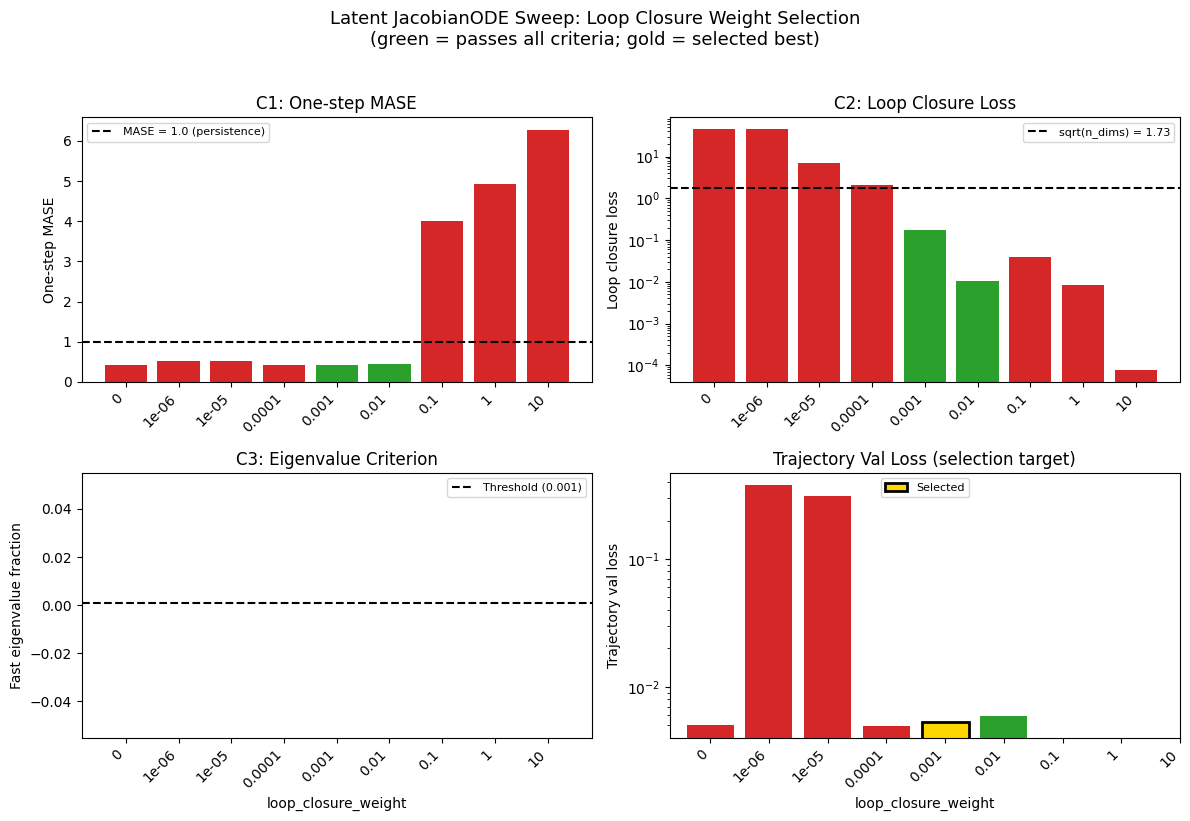

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

one_step_mases     = [m.one_step_mase             for m in all_diagnostics]
loop_closure_losses = [m.loop_closure_loss         for m in all_diagnostics]
eig_fracs          = [m.fast_eigenvalue_fraction   for m in all_diagnostics]
traj_losses        = [m.trajectory_val_loss        for m in all_diagnostics]

colors  = ['tab:green' if i in result.surviving_indices else 'tab:red'
           for i in range(len(all_diagnostics))]
x_labels = [str(v) for v in sweep_lambdas]
x_pos    = range(len(sweep_lambdas))

# Panel 1: One-step MASE vs persistence threshold (C1)
axes[0, 0].bar(x_pos, one_step_mases, color=colors)
axes[0, 0].axhline(1.0, color='k', ls='--',
                   label='MASE = 1.0 (persistence)')
axes[0, 0].set_ylabel('One-step MASE')
axes[0, 0].set_title('C1: One-step MASE')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(x_labels, rotation=45, ha='right')
axes[0, 0].legend(fontsize=8)

# Panel 2: Loop closure loss vs sqrt(n_dims) (C2)
axes[0, 1].bar(x_pos, loop_closure_losses, color=colors)
axes[0, 1].axhline(np.sqrt(n_dims), color='k', ls='--',
                   label=f'sqrt(n_dims) = {np.sqrt(n_dims):.2f}')
axes[0, 1].set_ylabel('Loop closure loss')
axes[0, 1].set_title('C2: Loop Closure Loss')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(x_labels, rotation=45, ha='right')
axes[0, 1].legend(fontsize=8)
axes[0, 1].set_yscale('log')

# Panel 3: Fast eigenvalue fraction (C3)
axes[1, 0].bar(x_pos, eig_fracs, color=colors)
axes[1, 0].axhline(0.001, color='k', ls='--', label='Threshold (0.001)')
axes[1, 0].set_ylabel('Fast eigenvalue fraction')
axes[1, 0].set_title('C3: Eigenvalue Criterion')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(x_labels, rotation=45, ha='right')
axes[1, 0].set_xlabel('loop_closure_weight')
axes[1, 0].legend(fontsize=8)

# Panel 4: Trajectory val loss (selection target)
axes[1, 1].bar(x_pos, traj_losses, color=colors)
if result.best_index is not None:
    axes[1, 1].bar(result.best_index, traj_losses[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[1, 1].set_ylabel('Trajectory val loss')
axes[1, 1].set_title('Trajectory Val Loss (selection target)')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(x_labels, rotation=45, ha='right')
axes[1, 1].set_xlabel('loop_closure_weight')
axes[1, 1].legend(fontsize=8)
axes[1, 1].set_yscale('log')

fig.suptitle(
    'Latent JacobianODE Sweep: Loop Closure Weight Selection\n'
    '(green = passes all criteria; gold = selected best)',
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

### 5e. Load the Best Model for Downstream Use

In [80]:
# idx = result.best_index
idx = 0

best_run_id  = sweep_run_ids[idx]
best_lambda  = sweep_lambdas[idx]

print(f"Loading best model: run_id={best_run_id}, params={best_lambda}")

Loading best model: run_id=vnlid970, lambda=0


In [81]:

# ----------------------------------------------------------------
# Load the trained run from Weights & Biases
# ----------------------------------------------------------------
# load_run now handles postprocessing (noise + normalization) internally
# and returns already-processed values.

# ---- Step 1: rebuild architecture + trajectory data (postprocessed) ----
run, cfg, eq, dt, values, _, _, _, _, lit_model = load_run(
    WANDB_PROJECT_PATH,
    run_id=best_run_id,
    save_dir=SAVE_DIR,
    generate_data=True,
    verbose=True,
)

# ---- Step 2: dataloaders from postprocessed data (also get full-obs test trajs) ----
train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values, verbose=True, return_full_obs=True)
test_trajs_full = trajs['test_trajs_full'].sequence  # (n_seqs, T_seq, 3) — full Lorenz dims

# ---- Step 3: load best checkpoint ----
load_checkpoint(run, cfg, lit_model, save_dir=SAVE_DIR, verbose=True)

# ---- Step 4: restore attributes not stored in the wandb config ----
lit_model.true_lyapunov_exponents = torch.tensor(TRUE_LYAPUNOV, dtype=torch.float32)
lit_model.jac_window_stride = JAC_WINDOW_STRIDE
lit_model.encoder_warmup_epochs = ENCODER_WARMUP_EPOCHS

lit_model.eval()
print(f"\nLoaded run: {run.name}  (id={run.id})")
print(f"  dt={dt:.4f}")
print(f"  jac_window_stride={lit_model.jac_window_stride}")
print(f"  encoder_warmup_epochs={lit_model.encoder_warmup_epochs}")
print(f"  true_lyapunov_exponents={lit_model.true_lyapunov_exponents.tolist()}")
print(f"  full-system test trajs: {test_trajs_full.shape}")
print(f"\nModel ready for testing (Sections 6+).")


Sequence Indices:   0%|          | 0/1130 [00:00<?, ?it/s]

Train dataset shape: torch.Size([24860, 70, 3])
Validation dataset shape: torch.Size([7910, 70, 3])
Test dataset shape: torch.Size([3390, 70, 3])
Train trajectories dataset shape: torch.Size([22, 1200, 3])
Validation trajectories dataset shape: torch.Size([7, 1200, 3])
Test trajectories dataset shape: torch.Size([3, 1200, 3])
Loading checkpoint epoch=82-step=16600.ckpt...

Loaded run: MLP__hidden_dim_[256, 1024, 2048, 2048]__num_layers_4__residuals_False__dropout_0.0__activation_silu__batch_size_32__optimizer_AdamW__optimizer_kwargs_{'lr': 5e-05, 'weight_decay': 0.0001}__use_scheduler_True__min_lr_1e-06__k_scale_1__gradient_clip_val_1.0__gradient_clip_algorithm_norm__alpha_teacher_forcing_1__teacher_forcing_annealing_True__gamma_teacher_forcing_0.999__teacher_forcing_update_interval_5__teacher_forcing_steps_1__min_alpha_teacher_forcing_0__alpha_validation_0__obs_noise_scale_0.0000__latent_noise_scale_0__latent_noise_per_step_False__precompute_latent_noise_factor_True__jac_penalty_0.0__

### 6. Testing

In [82]:
batch_indices     = np.random.choice(np.arange(len(test_dl.dataset.sequence)), size=(128,), replace=False)
sample_batch      = test_dl.dataset.sequence[batch_indices]
test_trajs        = trajs['test_trajs'].sequence        # partial-obs (1-D) — model input
sample_batch_full = test_trajs_full   # full-obs (3-D)  — ground truth


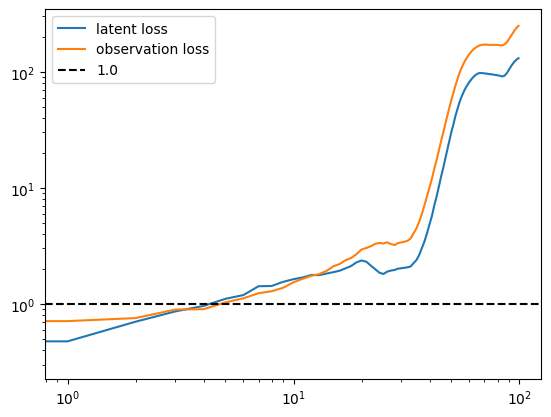

In [83]:
lit_model.prediction_steps = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lit_model = lit_model.to(device)
with torch.no_grad():
    traj_ret = lit_model.trajectory_model_step(test_trajs.to(device), alpha_teacher_forcing=0.0, return_decoded=True)
    targets = traj_ret['targets']
    decoded = traj_ret['decoded']
    latent_targets = lit_model.encode_trajectory(targets)
    z_pred = traj_ret['outputs']

per_time_step_latent_loss = ((latent_targets - z_pred[:, lit_model.jacobianODEint_kwargs['traj_init_steps']:])**2).mean(axis=(0, 2)).cpu().numpy()
ten_step_latent_loss = per_time_step_latent_loss[:10].mean()
plt.plot(per_time_step_latent_loss/ten_step_latent_loss, label='latent loss')

per_time_step_loss = ((targets.cpu() - decoded.cpu())**2).mean(axis=(0, 2))
ten_step_loss = per_time_step_loss[:10].mean()
plt.plot(per_time_step_loss/ten_step_loss, label='observation loss')

plt.axhline(1.0, color='k', linestyle='--', label='1.0')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.show()

In [84]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lit_model = lit_model.to(device)
lit_model.prediction_steps = PREDICTION_STEPS

# PROCESS SAMPLE BATCH
with torch.no_grad():
    sample_batch = sample_batch.to(device)
    latent_traj = lit_model.encode_trajectory(sample_batch)
    traj_decoded = lit_model.decode_trajectory(latent_traj)

    traj_ret = lit_model.trajectory_model_step(sample_batch, alpha_teacher_forcing=1.0, return_decoded=True)
    targets = traj_ret['targets']
    decoded = traj_ret['decoded']
    latent_targets = lit_model.encode_trajectory(targets)
    z_pred = traj_ret['outputs']

# move everything to cpu
sample_batch = sample_batch.cpu()
latent_traj = latent_traj.cpu()
traj_decoded = traj_decoded.cpu()
latent_targets = latent_targets.cpu()
z_pred = z_pred.cpu()
targets = targets.cpu()
decoded = decoded.cpu()

# PROCESS TEST TRAJS
with torch.no_grad():
    latent_traj_full = lit_model.encode_trajectory(test_trajs.to(device))
    traj_decoded_full = lit_model.decode_trajectory(latent_traj_full)
    jacs_full = lit_model.compute_jacobians(latent_traj_full)
    lyaps_full = lit_model.compute_lyapunov_exponents(jacs_full, dt)

# move everything to cpu
latent_traj_full = latent_traj_full.cpu()
traj_decoded_full = traj_decoded_full.cpu()
jacs_full = jacs_full.cpu()
lyaps_full = lyaps_full.cpu()
lit_model = lit_model.cpu()

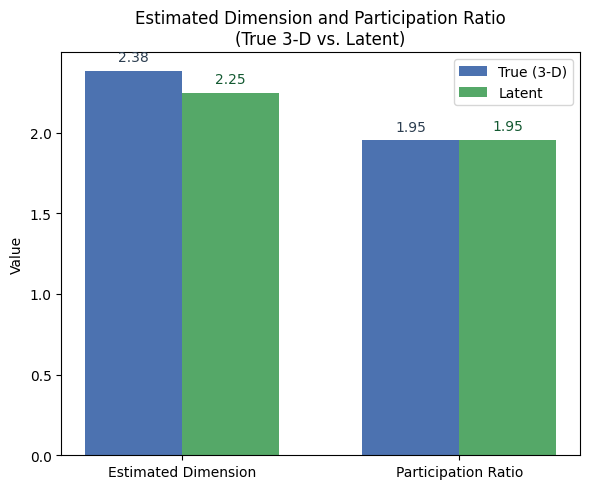

In [85]:
true_vars = test_trajs_full.reshape(-1, 3).var(axis=0)
est_dim_true = (true_vars / true_vars.max()).sum()
latent_vars = latent_traj_full.reshape(-1, latent_traj_full.shape[-1]).var(axis=0)
est_dim_latent = (latent_vars/latent_vars.max()).sum()

def participation_ratio(X):
    # X should be (N, D) where D is dimension
    X_flat = X.reshape(-1, X.shape[-1])
    cov = np.cov(X_flat, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    pr = (eigvals.sum())**2 / (eigvals**2).sum()
    return pr

pr_true = participation_ratio(test_trajs_full)
pr_latent = participation_ratio(latent_traj_full)

# Single grouped bar plot for Estimated Dimension & Participation Ratio
labels = ['Estimated Dimension', 'Participation Ratio']
true_values = [est_dim_true.item(), pr_true]
latent_values = [est_dim_latent.item(), pr_latent]

x = np.arange(len(labels))  # label locations
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(6, 5))
bars1 = ax.bar(x - width/2, true_values, width, label='True (3-D)', color='#4C72B0')
bars2 = ax.bar(x + width/2, latent_values, width, label='Latent', color='#55A868')

# Add value annotations
for bar in bars1:
    ax.annotate(f"{bar.get_height():.2f}", xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontsize=10, color='#2C3E50')
for bar in bars2:
    ax.annotate(f"{bar.get_height():.2f}", xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontsize=10, color='#145A32')

ax.set_ylabel('Value')
ax.set_title('Estimated Dimension and Participation Ratio\n(True 3-D vs. Latent)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.tight_layout()
plt.show()


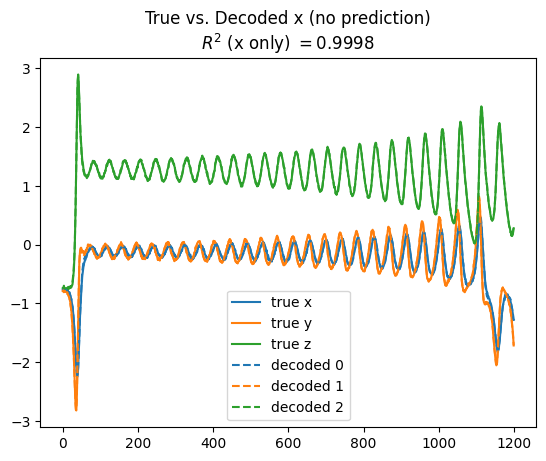

In [86]:
dim_names = ['x', 'y', 'z']
observed_indices = cfg.data.train_test_params.delay_embedding_params.observed_indices
# True 3-D Lorenz signal
for i in range(3):
    plt.plot(test_trajs_full[0, :, i].numpy(), c=f"C{i}", label=f'true {dim_names[i]}')
# Decoded signal is 1-D (model only reconstructs observed x)
for i in range(traj_decoded_full.shape[-1]):
    plt.plot(traj_decoded_full[0, :, i].numpy(), c=f"C{i}", linestyle='--', label=f'decoded {i}')
r2_x = r2_score(
    test_trajs.reshape(-1, test_trajs.shape[-1]),
    traj_decoded_full.reshape(-1, traj_decoded_full.shape[-1]),
)
plt.title(f"True vs. Decoded x (no prediction)\n$R^2$ (x only) $= {r2_x:.4f}$")
plt.legend()
plt.show()


In [87]:
W = lit_model.encoder.decoder.net[0].weight.data
cond_number = torch.linalg.cond(W)
singular_values = torch.linalg.svdvals(W)

print(f"Condition number of W: {cond_number.item():.4e}")
print("Singular values of W:", singular_values.cpu().numpy())

Condition number of W: 1.3107e+00
Singular values of W: [4.4515977 3.9529884 3.396433 ]


In [88]:
lyaps_full.mean(axis=0)

tensor([  0.1115,  -1.0262, -14.3060])

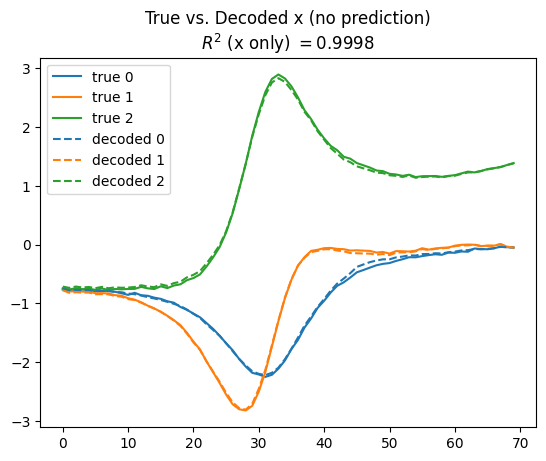

In [35]:
dim_names = ['x', 'y', 'z']
# plot the worst ind  (error measured on the observed x dimension)
plot_ind = ((sample_batch - traj_decoded)**2).mean(axis=(1, 2)).argmax()
# True 3-D signal
for i in range(sample_batch.shape[-1]):
    plt.plot(sample_batch[plot_ind, :, i].numpy(), c=f"C{i}", label=f'true {i}')
for i in range(traj_decoded.shape[-1]):
    plt.plot(traj_decoded[plot_ind, :, i].numpy(), c=f"C{i}", linestyle='--', label=f'decoded {i}')
r2_x = r2_score(
    sample_batch.reshape(-1, sample_batch.shape[-1]),
    traj_decoded.reshape(-1, traj_decoded.shape[-1]),
)
plt.title(f"True vs. Decoded x (no prediction)\n$R^2$ (x only) $= {r2_x:.4f}$")
plt.legend()
plt.show()


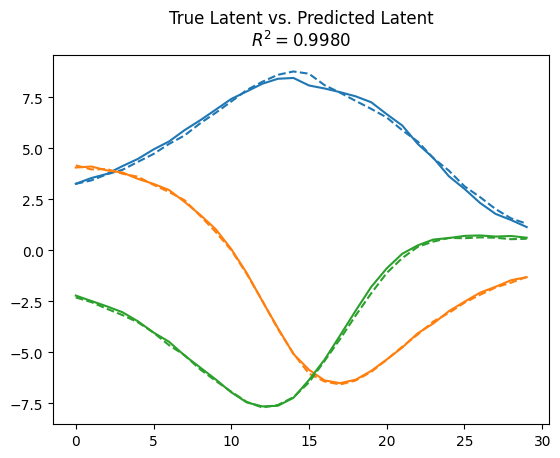

In [36]:
traj_init_steps = lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)
# plot the worst ind
plot_ind = ((latent_targets - z_pred[:, traj_init_steps:, :])**2).mean(axis=(1, 2)).argmax()
# plot_ind = ((latent_targets - z_pred[:, traj_init_steps:, :])**2).mean(axis=(1, 2)).argmin()
for i in range(latent_targets.shape[-1]):
    plt.plot(latent_targets[plot_ind, :, i].numpy(), c=f"C{i}", label=f'true latent {i + 1}')
    plt.plot(z_pred[plot_ind, traj_init_steps:, i].numpy(), c=f"C{i}", linestyle='--', label=f'predicted latent {i + 1}')
# plt.legend()
r2_val = r2_score(latent_targets.reshape(-1, 3), z_pred[:, traj_init_steps:, :].reshape(-1, 3))
plt.title(f"True Latent vs. Predicted Latent\n$R^2 = {r2_val:.4f}$")
plt.show()

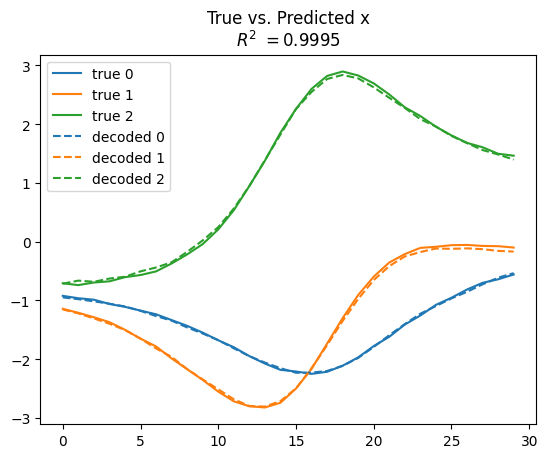

In [37]:
# True 3-D obs from sample_batch_full aligned to the prediction window.
# Window 0 targets: traj_init_steps : traj_init_steps + prediction_steps
traj_init_steps = lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)
_pred_steps = lit_model.prediction_steps

# plot_ind from the latent plot cell above; fall back to 0 if not set
try:
    plot_ind
except NameError:
    plot_ind = 0
_idx = plot_ind % len(targets)
for i in range(3):
    plt.plot(targets[_idx, :, i].numpy(), c=f"C{i}", label=f'true {i}')
# Decoded is 1-D — use window-0 entries (stride-spaced rows)
for i in range(decoded.shape[-1]):
    plt.plot(decoded[_idx, :, i].numpy(), c=f"C{i}", linestyle='--', label=f'decoded {i}')
r2_x = r2_score(
    targets.reshape(-1, targets.shape[-1]),
    decoded.reshape(-1, decoded.shape[-1]),
)
plt.legend()
plt.title(f"True vs. Predicted x\n$R^2$ $= {r2_x:.4f}$")
plt.show()


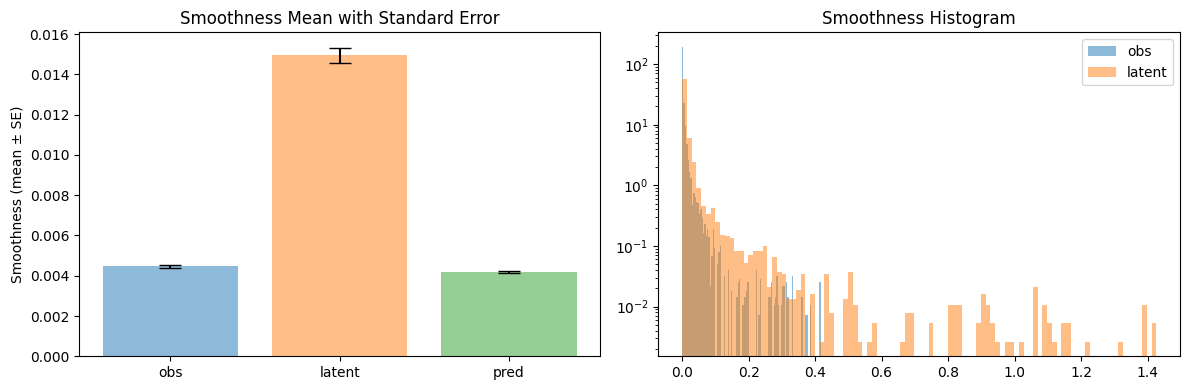

(0.0044594621285796165, 0.014944611117243767, 0.004198835697025061)

In [38]:
import matplotlib.pyplot as plt

# Compute smoothness
# smoothness = (targets[:, 1:] - targets[:, :-1]).pow(2)/targets.var(axis=(0, 1)).unsqueeze(0).unsqueeze(0)
# smoothness_latents = (latent_traj[:, 1:] - latent_traj[:, :-1]).pow(2)/latent_traj.var(axis=(0, 1)).unsqueeze(0).unsqueeze(0)
# smoothness_pred = (decoded[:, 1:] - decoded[:, :-1]).pow(2)/decoded.var(axis=(0, 1)).unsqueeze(0).unsqueeze(0)
# use overall variance
smoothness = (targets[:, 1:] - targets[:, :-1]).pow(2)/targets.var()
smoothness_latents = (latent_traj[:, 1:] - latent_traj[:, :-1]).pow(2)/latent_traj.var()
smoothness_pred = (decoded[:, 1:] - decoded[:, :-1]).pow(2)/decoded.var()

# Means and standard errors
means = [
    smoothness.mean().item(),
    smoothness_latents.mean().item(),
    smoothness_pred.mean().item(),
]
std_errors = [
    smoothness.flatten().std(unbiased=True).item() / (smoothness.numel() ** 0.5),
    smoothness_latents.flatten().std(unbiased=True).item() / (smoothness_latents.numel() ** 0.5),
    smoothness_pred.flatten().std(unbiased=True).item() / (smoothness_pred.numel() ** 0.5),
]
labels = ['obs', 'latent', 'pred']

# Plotting: Subplot with bargraph and histogram
fig, axs = plt.subplots(1, 2, figsize=(12,4))

# Bar plot with error bars
axs[0].bar(labels, means, yerr=std_errors, capsize=8, color=['C0', 'C1', 'C2'], alpha=0.5)
axs[0].set_ylabel('Smoothness (mean ± SE)')
axs[0].set_title('Smoothness Mean with Standard Error')

# Old histogram plot (for comparison)
axs[1].hist(smoothness.flatten().cpu().numpy(), bins=100, density=True, label='obs', alpha=0.5)
axs[1].hist(smoothness_latents.flatten().cpu().numpy(), bins=100, density=True, label='latent', alpha=0.5)
# axs[1].hist(smoothness_pred.flatten().cpu().numpy(), bins=100, density=True, label='pred', alpha=0.5)
axs[1].set_yscale('log')
axs[1].set_title("Smoothness Histogram")
axs[1].legend()

plt.tight_layout()
plt.show()

(means[0], means[1], means[2])

### Smoothness: Second-Order Finite Differences (Linearity Penalty)

$$L_{\text{lin}} = \left\| (\hat{x}_{t+1} - \hat{x}_t) - (\hat{x}_t - \hat{x}_{t-1}) \right\|^2$$

This penalizes changes in the numerical derivative — trajectories that are locally linear (constant velocity) will have low values.

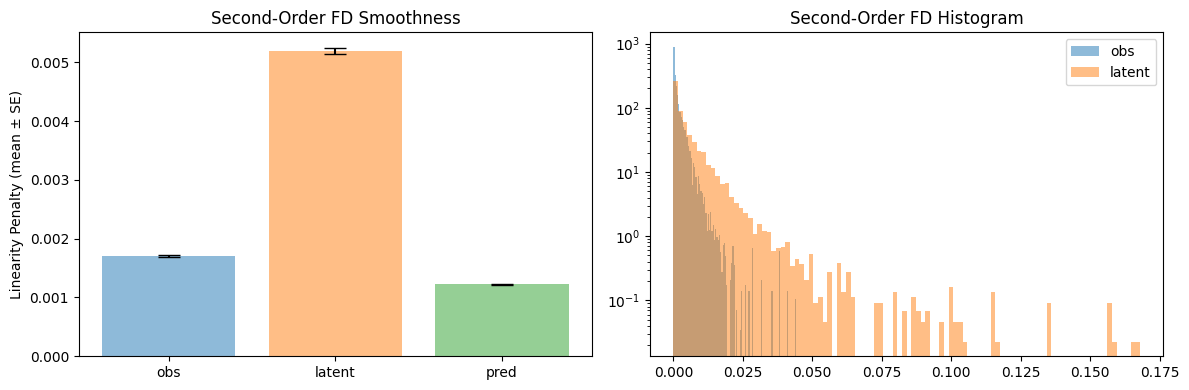

(0.0017048162408173084, 0.005191135685890913, 0.0012269591679796576)

In [39]:
# Second-order finite differences (linearity penalty)
# L_lin = || (x_{t+1} - x_t) - (x_t - x_{t-1}) ||^2  (variance-normalized)

def second_order_fd(x):
    """Compute variance-normalized second-order finite differences."""
    # x: (B, T, D)
    d_fwd = x[:, 1:, :] - x[:, :-1, :]   # (B, T-1, D)
    dd = d_fwd[:, 1:, :] - d_fwd[:, :-1, :]  # (B, T-2, D)
    # var = x.var(dim=(0, 1)).unsqueeze(0).unsqueeze(0)  # (1, 1, D)
    # overall variance
    var = x.var()
    return dd.pow(2) / var

lin_obs     = second_order_fd(targets)
lin_latents = second_order_fd(latent_traj)
lin_pred    = second_order_fd(decoded)

# Means and standard errors
means_lin = [
    lin_obs.mean().item(),
    lin_latents.mean().item(),
    lin_pred.mean().item(),
]
std_errors_lin = [
    lin_obs.flatten().std(unbiased=True).item() / (lin_obs.numel() ** 0.5),
    lin_latents.flatten().std(unbiased=True).item() / (lin_latents.numel() ** 0.5),
    lin_pred.flatten().std(unbiased=True).item() / (lin_pred.numel() ** 0.5),
]
labels = ['obs', 'latent', 'pred']

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].bar(labels, means_lin, yerr=std_errors_lin, capsize=8, color=['C0', 'C1', 'C2'], alpha=0.5)
axs[0].set_ylabel('Linearity Penalty (mean ± SE)')
axs[0].set_title('Second-Order FD Smoothness')

axs[1].hist(lin_obs.flatten().cpu().numpy(), bins=100, density=True, label='obs', alpha=0.5)
axs[1].hist(lin_latents.flatten().cpu().numpy(), bins=100, density=True, label='latent', alpha=0.5)
axs[1].set_yscale('log')
axs[1].set_title('Second-Order FD Histogram')
axs[1].legend()

plt.tight_layout()
plt.show()

(means_lin[0], means_lin[1], means_lin[2])

### Smoothness: Vector Field Consistency

$$L_{\text{consistency}} = \left\| \hat{x}_{t+1} - \left(\hat{x}_t + \hat{f}(\hat{x}_t)\,\Delta t\right) \right\|^2$$

Measures how well a single Euler step with the vector field predicts the next point.

- **Observations**: Uses the *true* Lorenz vector field `eq.rhs` (states un-normalized first).
- **Latent space**: Uses the JacobianODE-estimated vector field via `get_deriv_func` (requires `traj_init_steps` context points).
- **Decoded**: Decodes both actual and Euler-predicted latents, compares in observation space.

traj_init_steps = 15


Computing latent f via JacobianODE:   0%|          | 0/55 [00:00<?, ?it/s]

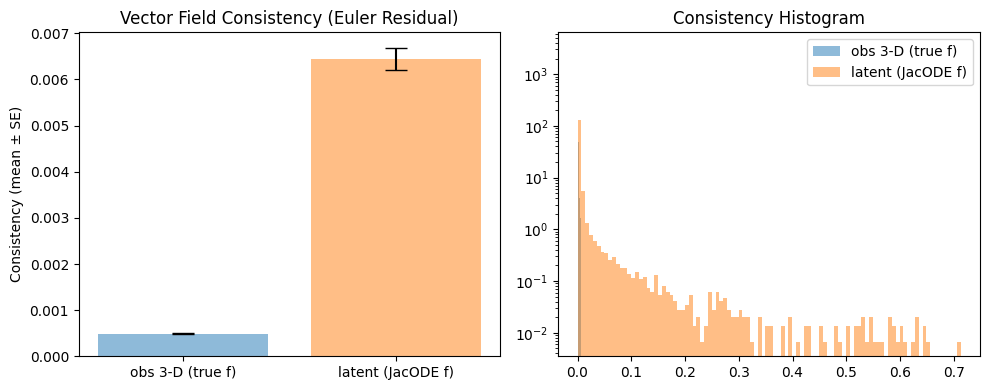

(0.0004915407043881714, 0.0064501469023525715)

In [40]:
from JacobianODE.jacobians.jacobianODE import JacobianODE, JacobianODEint

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lit_model_dev = lit_model.to(device)
lit_model_dev.eval()

traj_init_steps = lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)
print(f"traj_init_steps = {traj_init_steps}")

# ---------------------------------------------------------------
# 1. Observations: true Lorenz vector field on full-system test trajs
# ---------------------------------------------------------------
obs_ref_raw = (test_trajs_full * sigma + mu).numpy()   # (n_seqs, T_seq, 3)
t_dummy_ref = np.zeros(obs_ref_raw.shape[1])

f_obs_raw = np.zeros_like(obs_ref_raw)
for b in range(obs_ref_raw.shape[0]):
    f_obs_raw[b] = eq.rhs(obs_ref_raw[b], t_dummy_ref)

f_obs = torch.from_numpy(f_obs_raw).float() / sigma

obs_ref = test_trajs_full   # normalised 3-D
euler_resid_obs = obs_ref[:, 1:, :] - (obs_ref[:, :-1, :] + f_obs[:, :-1, :] * dt)
obs_var = obs_ref.var()
cons_obs = euler_resid_obs.pow(2) / obs_var

# ---------------------------------------------------------------
# 2. Latent space: JacobianODE-estimated vector field (batched)
# ---------------------------------------------------------------
latent_traj_dev = latent_traj.to(device)
B, T, D = latent_traj.shape
T_pred = T - traj_init_steps

time_vals = (torch.arange(traj_init_steps) * dt).to(device).float()
z_init_all = latent_traj_dev[:, :traj_init_steps, :]

jac_ode = JacobianODE(z_init_all, lit_model_dev.compute_jacobians, time_vals)
f_func = jac_ode.get_deriv_func(
    t_0=time_vals[0],
    inner_path="line",
    fast_mode=True,
    fast_mode_base_ind=traj_init_steps - 1,
    scale_interp_pts=True,
    interp_pts=4,
)

f_latent = torch.zeros(B, T_pred, D)
for k in tqdm(range(T_pred), desc="Computing latent f via JacobianODE"):
    t_k = torch.tensor((traj_init_steps + k) * dt, dtype=torch.float32, device=device)
    z_k = latent_traj_dev[:, traj_init_steps + k, :]
    f_val = f_func(t_k, z_k)
    f_latent[:, k] = f_val.detach().cpu()

euler_pred_latent = latent_traj[:, traj_init_steps:-1, :] + f_latent[:, :-1, :] * dt
cons_latent_raw = (latent_traj[:, traj_init_steps+1:, :] - euler_pred_latent).pow(2)
latent_var = latent_traj.var()
cons_latent = cons_latent_raw / latent_var

lit_model_dev = lit_model_dev.cpu()

# ---------------------------------------------------------------
# Plot (obs 3-D vs latent; decoder is 1-D so "decoded" bar is omitted)
# ---------------------------------------------------------------
means_cons = [
    cons_obs.mean().item(),
    cons_latent.mean().item(),
]
std_errors_cons = [
    cons_obs.flatten().std(unbiased=True).item() / (cons_obs.numel() ** 0.5),
    cons_latent.flatten().std(unbiased=True).item() / (cons_latent.numel() ** 0.5),
]
labels = ['obs 3-D (true f)', 'latent (JacODE f)']

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].bar(labels, means_cons, yerr=std_errors_cons, capsize=8, color=['C0', 'C1'], alpha=0.5)
axs[0].set_ylabel('Consistency (mean ± SE)')
axs[0].set_title('Vector Field Consistency (Euler Residual)')

axs[1].hist(cons_obs.flatten().cpu().numpy(), bins=100, density=True, label='obs 3-D (true f)', alpha=0.5)
axs[1].hist(cons_latent.flatten().detach().cpu().numpy(), bins=100, density=True, label='latent (JacODE f)', alpha=0.5)
axs[1].set_yscale('log')
axs[1].set_title('Consistency Histogram')
axs[1].legend()

plt.tight_layout()
plt.show()

(means_cons[0], means_cons[1])


### Smoothness: Jacobian Regularity (Vector Field Acceleration)

$$\frac{d}{dt} L_{\text{reg}} = \| J_f(\mathbf{x})\, f(\mathbf{x}) \|^2$$

This measures the **acceleration** of the vector field along trajectories: $J_f(x)\,f(x) = \frac{d}{dt} f(x(t))$.
Low values mean the vector field changes slowly along the flow — the dynamics are smooth/regular.

- **Observations**: Uses the true Lorenz Jacobian `eq.jac` and vector field `eq.rhs` (un-normalized).
- **Latent space (learned J)**: Uses the model's predicted Jacobian and the JacobianODE-estimated vector field `f_latent` from above.
- **Latent/Decoded (numerical)**: Uses second finite differences as a numerical approximation.

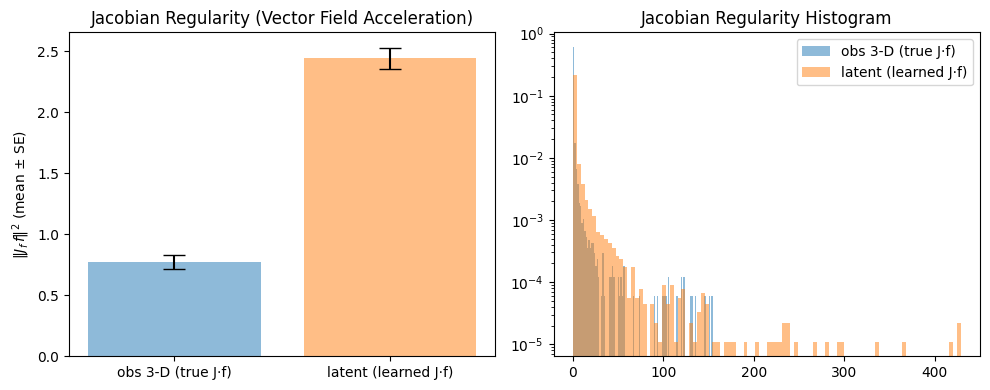

obs 3-D (true J·f): 0.773348
latent (learned J·f): 2.442493


In [41]:
# Jacobian regularity penalty: || J_f(x) f(x) ||^2

# ---------------------------------------------------------------
# 1. Observations: true Lorenz J and f on full-system test trajs
# ---------------------------------------------------------------
# obs_ref_raw: (n_seqs, T_seq, 3) and f_obs_raw: (n_seqs, T_seq, 3) from cell 50
t_dummy_obs = np.zeros(obs_ref_raw.shape[1])
J_obs_raw = eq.jac(obs_ref_raw, t_dummy_obs)          # (n_seqs, T_seq, 3, 3)
Jf_obs_raw = np.einsum('btij,btj->bti', J_obs_raw, f_obs_raw)
Jf_obs_norm = torch.from_numpy(Jf_obs_raw).float() / sigma
obs_var = obs_ref.var()
jreg_obs = Jf_obs_norm.pow(2) / (obs_var / dt**2)

# ---------------------------------------------------------------
# 2. Latent space: learned J and JacobianODE f
# ---------------------------------------------------------------
lit_model_dev = lit_model.to(device)
lit_model_dev.eval()
with torch.no_grad():
    jacs = lit_model_dev.compute_jacobians(latent_traj.to(device)).cpu()
lit_model_dev = lit_model_dev.cpu()

jacs_at_pred = jacs[:, traj_init_steps:, :, :]
Jf_latent = torch.einsum('btij,btj->bti', jacs_at_pred, f_latent)
latent_var = latent_traj.var()
jreg_latent = Jf_latent.pow(2) / (latent_var / dt**2)

# ---------------------------------------------------------------
# Plot (obs 3-D vs latent; decoder is 1-D so "decoded" bar is omitted)
# ---------------------------------------------------------------
means_jreg = [
    jreg_obs.mean().item(),
    jreg_latent.mean().item(),
]
std_errors_jreg = [
    jreg_obs.flatten().std(unbiased=True).item() / (jreg_obs.numel() ** 0.5),
    jreg_latent.flatten().detach().std(unbiased=True).item() / (jreg_latent.numel() ** 0.5),
]
labels_jreg = ['obs 3-D (true J·f)', 'latent (learned J·f)']

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].bar(labels_jreg, means_jreg, yerr=std_errors_jreg, capsize=8,
           color=['C0', 'C1'], alpha=0.5)
axs[0].set_ylabel(r'$\|J_f\, f\|^2$ (mean ± SE)')
axs[0].set_title('Jacobian Regularity (Vector Field Acceleration)')

axs[1].hist(jreg_obs.flatten().cpu().numpy(), bins=100, density=True, label='obs 3-D (true J·f)', alpha=0.5)
axs[1].hist(jreg_latent.flatten().detach().cpu().numpy(), bins=100, density=True, label='latent (learned J·f)', alpha=0.5)
axs[1].set_yscale('log')
axs[1].set_title('Jacobian Regularity Histogram')
axs[1].legend()

plt.tight_layout()
plt.show()

for lbl, val in zip(labels_jreg, means_jreg):
    print(f"{lbl}: {val:.6f}")


### Jacobian-Consistency (Velocity Propagation)

$$L_{\text{jac-cons}} = \left\| (x_{t+2} - x_{t+1}) - e^{\hat{J}\,\Delta t}(x_{t+1} - x_t) \right\|^2$$

This tests whether the learned Jacobian correctly propagates velocity vectors forward in time. From the **variational equation** of the ODE: if $\dot{x} = f(x)$, then a displacement $\delta x$ evolves as $\dot{\delta x} = J_f(x)\,\delta x$, so $\delta x(t+\Delta t) \approx e^{J\Delta t}\,\delta x(t)$.

Here $x_{t+1} - x_t$ is the empirical velocity — if $\hat{J}$ is correct, $e^{\hat{J}\Delta t}$ maps it to the next-step velocity $x_{t+2} - x_{t+1}$.

Unlike the Euler-residual consistency, **no `get_deriv_func` or JacobianODE is needed** — only `compute_jacobians` + the trajectory.

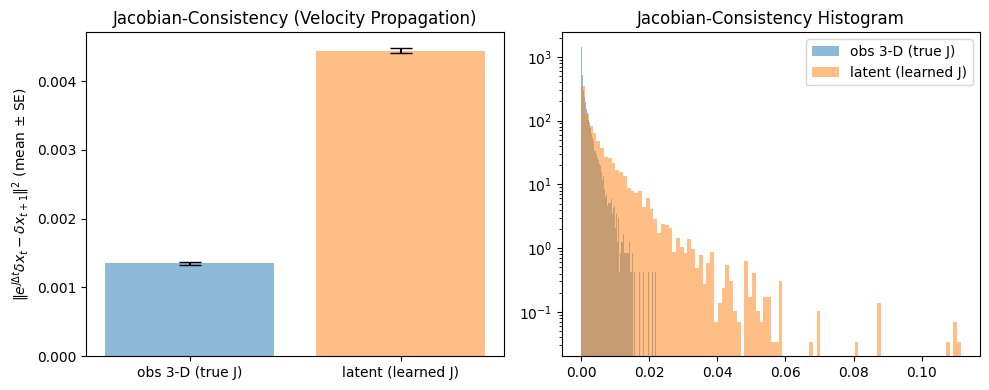

obs 3-D (true J): 0.001351
latent (learned J): 0.004442


In [42]:
# Jacobian-consistency: ||(x_{t+2} - x_{t+1}) - exp(J*dt) @ (x_{t+1} - x_t)||^2

# ---------------------------------------------------------------
# 1. Observations: true Lorenz J on full-system test trajs
# ---------------------------------------------------------------
# J_obs_raw: (n_seqs, T_seq, 3, 3) from jreg cell
J_obs_exp = torch.matrix_exp(torch.from_numpy(J_obs_raw[:, :-2]).float() * dt)  # (B, T-2, 3, 3)

vel_obs_raw = torch.from_numpy(obs_ref_raw[:, 1:] - obs_ref_raw[:, :-1]).float()
vel_obs_t  = vel_obs_raw[:, :-1]
vel_obs_t1 = vel_obs_raw[:, 1:]

vel_obs_t1_pred = (J_obs_exp @ vel_obs_t.unsqueeze(-1)).squeeze(-1)
residual_obs_raw = vel_obs_t1 - vel_obs_t1_pred
residual_obs_norm = residual_obs_raw / sigma
jac_cons_obs = residual_obs_norm.pow(2) / obs_ref.var()

# ---------------------------------------------------------------
# 2. Latent: learned J (reuse jacs from jreg cell)
# ---------------------------------------------------------------
J_lat_exp = torch.matrix_exp(jacs[:, :-2] * dt)

vel_lat = latent_traj[:, 1:] - latent_traj[:, :-1]
vel_lat_t  = vel_lat[:, :-1]
vel_lat_t1 = vel_lat[:, 1:]

vel_lat_t1_pred = (J_lat_exp @ vel_lat_t.unsqueeze(-1)).squeeze(-1)
residual_lat = vel_lat_t1 - vel_lat_t1_pred
jac_cons_latent = residual_lat.pow(2) / latent_traj.var()

# ---------------------------------------------------------------
# Plot (obs 3-D vs latent; decoder is 1-D so "decoded" bar is omitted)
# ---------------------------------------------------------------
means_jc = [
    jac_cons_obs.mean().item(),
    jac_cons_latent.mean().item(),
]
std_errors_jc = [
    jac_cons_obs.flatten().std(unbiased=True).item() / (jac_cons_obs.numel() ** 0.5),
    jac_cons_latent.flatten().std(unbiased=True).item() / (jac_cons_latent.numel() ** 0.5),
]
labels_jc = ['obs 3-D (true J)', 'latent (learned J)']

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].bar(labels_jc, means_jc, yerr=std_errors_jc, capsize=8,
           color=['C0', 'C1'], alpha=0.5)
axs[0].set_ylabel(r'$\|e^{J\Delta t}\delta x_t - \delta x_{t+1}\|^2$ (mean ± SE)')
axs[0].set_title('Jacobian-Consistency (Velocity Propagation)')

axs[1].hist(jac_cons_obs.flatten().cpu().numpy(), bins=100, density=True, label='obs 3-D (true J)', alpha=0.5)
axs[1].hist(jac_cons_latent.flatten().detach().cpu().numpy(), bins=100, density=True, label='latent (learned J)', alpha=0.5)
axs[1].set_yscale('log')
axs[1].set_title('Jacobian-Consistency Histogram')
axs[1].legend()

plt.tight_layout()
plt.show()

for lbl, val in zip(labels_jc, means_jc):
    print(f"{lbl}: {val:.6f}")


## Composite Jacobian: $J_D \, J_{\mathrm{ODE}} \, J_E \approx J_{\mathrm{true}}$

We verify that the autodifferentiated composition of encoder, predicted latent
Jacobian, and decoder recovers the true Lorenz Jacobian.

**Three Jacobians**:
| Symbol | Shape | Computed via |
|--------|-------|--------------|
| $J_E = \partial z_t / \partial x_t$ | (3, 3) | `autograd` through SSM encoder |
| $J_{\mathrm{ODE}}$ | (3, 3) | Jacobian MLP output at $z_t$ |
| $J_D = \partial \hat{x}_t / \partial z_t$ | (3, 3) | `autograd` through pointwise decoder |

**Lorenz Jacobian** at $x = (x_1, x_2, x_3)$ (in normalized coords = same as raw since normalization is a global scalar):
$$
J_{\mathrm{true}}(x) = \begin{pmatrix}
-\sigma & \sigma & 0 \\
\rho - x_3 & -1 & -x_1 \\
x_2 & x_1 & -\beta
\end{pmatrix}
$$

**Expected result**: $J_D J_{\mathrm{ODE}} J_E \approx J_{\mathrm{true}}$ entry-by-entry.

In [43]:
# ---------------------------------------------------------------
# Helper: analytical Lorenz Jacobian
# Note: Since normalization is x_norm = (x - mu)/sigma (global scalar),
# J_lorenz(x_norm) == J_lorenz(x_raw).  Pass denormalized x.
# ---------------------------------------------------------------
def lorenz_jacobian(x_raw, sigma_lz=10.0, rho=28.0, beta=8.0/3.0):
    """Analytical Lorenz Jacobian at x_raw = (x1, x2, x3)."""
    x1, x2, x3 = float(x_raw[0]), float(x_raw[1]), float(x_raw[2])
    return torch.tensor([
        [-sigma_lz, sigma_lz,    0.0 ],
        [rho - x3,  -1.0,       -x1  ],
        [x2,         x1,        -beta],
    ], dtype=torch.float32)


# ---------------------------------------------------------------
# Helper: encoder Jacobian  J_E = d(z_t)/d(x_t)
# We replace x_t in the full sequence and differentiate.
# For the SSM this gives the *partial* Jacobian w.r.t. x_t
# (history x_{0:t-1} is treated as fixed constants).
# ---------------------------------------------------------------
def compute_J_E(lit_model, x_seq, t_idx):
    """
    Args:
        x_seq : (1, T, D_obs) — single sequence (batch dim = 1)
        t_idx : int           — timestep to differentiate at
    Returns:
        J_E : (D_latent, D_obs) tensor
    """
    x_detached = x_seq.detach()

    def f(x_t):
        # x_t: (D_obs,) — the input we differentiate w.r.t.
        x_new = torch.cat([
            x_detached[:, :t_idx, :],
            x_t.view(1, 1, -1),
            x_detached[:, t_idx+1:, :],
        ], dim=1)  # (1, T, D_obs)
        z = lit_model.encoder.encode(x_new)  # (1, T, D_latent)
        return z[0, t_idx]                   # (D_latent,)

    return autograd_jacobian(f, x_detached[0, t_idx])  # (D_latent, D_obs)


# ---------------------------------------------------------------
# Helper: decoder Jacobian  J_D = d(decode(z_t))/d(z_t)
# ---------------------------------------------------------------
def compute_J_D(lit_model, z_t):
    """
    Args:
        z_t : (D_latent,) tensor
    Returns:
        J_D : (D_obs, D_latent) tensor
    """
    def f(z):
        # z: (D_latent,) → (D_obs,)
        return lit_model.encoder.decode(z.unsqueeze(0)).squeeze(0)

    return autograd_jacobian(f, z_t)  # (D_obs, D_latent)


# ---------------------------------------------------------------
# Helper: predicted latent Jacobian  J_ODE = Jac MLP at z_t
# ---------------------------------------------------------------
def compute_J_ODE(lit_model, z_t):
    """
    Args:
        z_t : (D_latent,) tensor
    Returns:
        J_ODE : (D_latent, D_latent) tensor
    """
    return lit_model.compute_jacobians(
        z_t.unsqueeze(0).unsqueeze(0)  # (1, 1, D_latent)
    )[0, 0]                            # (D_latent, D_latent)


print("Helper functions defined.")

Helper functions defined.


In [44]:
# ---------------------------------------------------------------
# Compute composite Jacobians on a test trajectory (GPU if available)
# ---------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lit_model = lit_model.to(device)
lit_model.eval()

# Partial-obs sequence for model input (encoder expects 1-D observations)
test_seq      = trajs['test_trajs'].sequence[:1].to(device)   # (1, T, 1)
# Full-system sequence for true Lorenz Jacobian (needs 3-D state)
test_seq_full = test_trajs_full[:1].to(device)                 # (1, T, 3)
T_test = test_seq.shape[1]

def to_device(x, device):
    if torch.is_tensor(x):
        return x.to(device)
    return torch.tensor(x, dtype=torch.float32, device=device)

sigma_device = to_device(sigma, device)
mu_device    = to_device(mu, device)

STEP    = 2
T_START = 5
t_indices = range(T_START, T_test - 1, STEP)

J_composites = []
J_trues      = []

with torch.no_grad():
    z_seq = lit_model.encode_trajectory(test_seq)  # (1, T', D_latent) from partial-obs input

for t_idx in tqdm(t_indices):
    z_t   = z_seq[0, t_idx].detach()
    # Full-system state for the true Lorenz Jacobian
    x_t_n = test_seq_full[0, t_idx].detach()      # (3,)

    with torch.no_grad():
        J_ode = compute_J_ODE(lit_model, z_t)

    with torch.enable_grad():
        J_d = compute_J_D(lit_model, z_t)

    with torch.enable_grad():
        J_e = compute_J_E(lit_model, test_seq, t_idx)

    J_comp = J_d @ J_ode @ J_e

    x_raw = x_t_n * sigma_device + mu_device   # denormalize (3-D)
    J_true = lorenz_jacobian(x_raw)

    J_composites.append(J_comp.detach().cpu())
    if torch.is_tensor(J_true):
        J_trues.append(J_true.detach().cpu())
    else:
        J_trues.append(torch.as_tensor(J_true, dtype=torch.float32).cpu())

J_composites = torch.stack(J_composites)    # (N_t, D_obs, D_obs)
J_trues      = torch.stack(J_trues)         # (N_t, 3, 3)

print(f"Evaluated {len(t_indices)} timesteps.")
print(f"J_composites shape: {J_composites.shape}  (composite: D_obs x D_obs)")
print(f"J_trues      shape: {J_trues.shape}        (true Lorenz: 3x3)")


  0%|          | 0/597 [00:00<?, ?it/s]

Evaluated 597 timesteps.
J_composites shape: torch.Size([597, 3, 3])  (composite: D_obs x D_obs)
J_trues      shape: torch.Size([597, 3, 3])        (true Lorenz: 3x3)


In [45]:
# ---------------------------------------------------------------
# Summary metrics
# ---------------------------------------------------------------
frob_errors = torch.norm(J_composites - J_trues, dim=(-2, -1))   # (N_t,)
frob_true   = torch.norm(J_trues,                dim=(-2, -1))
rel_errors  = frob_errors / (frob_true + 1e-8)

# Pearson correlation across all (i,j) entries and timesteps
comp_flat = J_composites.reshape(-1).numpy()
true_flat = J_trues.reshape(-1).numpy()
corr = float(np.corrcoef(comp_flat, true_flat)[0, 1])
r2_val = r2_score(true_flat, comp_flat)

print("Composite Jacobian test results")
print("=" * 38)
print(f"Frobenius error  — mean: {frob_errors.mean():.4f}  |  std: {frob_errors.std():.4f}")
print(f"Relative error   — mean: {rel_errors.mean():.4f}  |  std: {rel_errors.std():.4f}")
print(f"Entry correlation:       {corr:.4f}")
print(f"R^2:                     {r2_val:.4f}")

# Per-entry breakdown
print("\nPer-entry mean absolute error:")
mae_matrix = (J_composites - J_trues).abs().mean(dim=0).numpy()
print(np.round(mae_matrix, 4))

print("\nMean composite Jacobian:")
print(np.round(J_composites.mean(dim=0).numpy(), 3))

print("\nMean true Lorenz Jacobian:")
print(np.round(J_trues.mean(dim=0).numpy(), 3))

Composite Jacobian test results
Frobenius error  — mean: 13.2939  |  std: 4.1966
Relative error   — mean: 0.6169  |  std: 0.1134
Entry correlation:       0.7640
R^2:                     0.5820

Per-entry mean absolute error:
[[7.5765 4.3364 2.7703]
 [5.776  3.1676 1.9238]
 [4.2462 1.9947 1.4531]]

Mean composite Jacobian:
[[-2.448  5.664 -2.185]
 [-3.071  1.366 -5.02 ]
 [ 3.377  8.105 -1.254]]

Mean true Lorenz Jacobian:
[[-10.     10.      0.   ]
 [  2.507  -1.     -6.621]
 [  6.592   6.621  -2.667]]


## False Nearest Neighbors (FNN) Loss

Computes the FNN loss from Gilpin (NeurIPS 2020) / Kennel et al. (1992) via `loss_false` in `JacobianODE.fnn`.

For each embedding dimension $d$, a nearest-neighbor pair is "false" if adding coordinate $d{+}1$ reveals them to be far apart (ratio criterion $> 20$ or size criterion $> 2\times$ attractor scale). The loss weights each latent dimension's mean-squared activation by its fraction of **true** (non-false) neighbors — dimensions unused by the data get full weight and are suppressed toward zero.

We compare:
- **True state** — `test_trajs_full` flattened to $(N, 3)$
- **Latent embeddings** — `latent_traj_full` flattened to $(N, D_\text{latent})$

FNN loss — True state (3-D):   0.683679
FNN loss — Latent embeddings:  0.269595


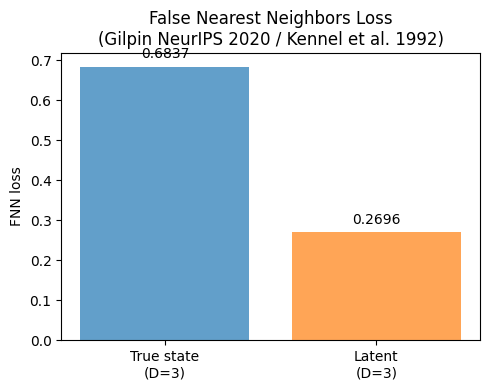

In [48]:
from JacobianODE.fnn import loss_false

# ---------------------------------------------------------------
# Flatten (B, T, D) → (N, D) and subsample
# ---------------------------------------------------------------
rng_fnn  = np.random.default_rng(42)

X_true   = test_trajs_full.reshape(-1, test_trajs_full.shape[-1]).float()      # (N, 3)
X_latent = latent_traj_full.reshape(-1, latent_traj_full.shape[-1]).float()    # (N, D_latent)
N_POINTS = len(X_true)
idx_true   = rng_fnn.choice(len(X_true),   N_POINTS, replace=False)
idx_latent = rng_fnn.choice(len(X_latent), N_POINTS, replace=False)

X_true_sub   = X_true[torch.from_numpy(idx_true)]
X_latent_sub = X_latent[torch.from_numpy(idx_latent)]

with torch.no_grad():
    fnn_loss_true   = loss_false(X_true_sub, k=2, normalize=True).item()
    fnn_loss_latent = loss_false(X_latent_sub, k=2, normalize=True).item()

print(f"FNN loss — True state (3-D):   {fnn_loss_true:.6f}")
print(f"FNN loss — Latent embeddings:  {fnn_loss_latent:.6f}")

# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------
D_latent = X_latent.shape[-1]
labels   = [f'True state\n(D=3)', f'Latent\n(D={D_latent})']
values   = [fnn_loss_true, fnn_loss_latent]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, values, color=['C0', 'C1'], alpha=0.7)
ax.set_ylabel('FNN loss')
ax.set_title('False Nearest Neighbors Loss\n(Gilpin NeurIPS 2020 / Kennel et al. 1992)')
for bar, val in zip(bars, values):
    ax.annotate(f'{val:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom')
plt.tight_layout()
plt.show()


In [49]:
# Center the data (subtract mean)
X_true_mean = X_true_sub.mean(dim=0, keepdim=True)
X_true_centered = X_true_sub - X_true_mean

# Compute covariance matrix
cov = X_true_centered.T @ X_true_centered / (X_true_centered.shape[0] - 1)

# Compute eigenvalues and eigenvectors
eigvals, eigvecs = torch.linalg.eigh(cov)  # outputs are ascending

# Sort by largest eigenvalue first
idxs = torch.argsort(eigvals, descending=True)
eigvecs = eigvecs[:, idxs]  # (3, 3), principal components (directions)

# Project X_true_sub into PCA basis (columns of eigvecs)
X_true_pca = X_true_centered @ eigvecs

# X_true_pca now has columns ordered by decreasing variance
print("PCA projection shape:", X_true_pca.shape)

fnn_loss_true_pca   = loss_false(X_true_pca, k=2, normalize=True).item()

# Center the latent data (subtract mean)
X_latent_mean = X_latent_sub.mean(dim=0, keepdim=True)
X_latent_centered = X_latent_sub - X_latent_mean

# Compute covariance matrix for latents
cov_latent = X_latent_centered.T @ X_latent_centered / (X_latent_centered.shape[0] - 1)

# Compute eigenvalues and eigenvectors for latents
eigvals_latent, eigvecs_latent = torch.linalg.eigh(cov_latent)  # outputs are ascending

# Sort by largest eigenvalue first
idxs_latent = torch.argsort(eigvals_latent, descending=True)
eigvecs_latent = eigvecs_latent[:, idxs_latent]  # (D_latent, D_latent), principal components

# Project X_latent_sub into PCA basis (columns of eigvecs_latent)
X_latent_pca = X_latent_centered @ eigvecs_latent

# X_latent_pca now has columns ordered by decreasing variance
print("Latent PCA projection shape:", X_latent_pca.shape)

fnn_loss_latent_pca = loss_false(X_latent_pca, k=2, normalize=True).item()

print(f"FNN loss — True state (PCA):        {fnn_loss_true_pca:.6f}")
print(f"FNN loss — Latent embeddings (PCA): {fnn_loss_latent_pca:.6f}")

PCA projection shape: torch.Size([3600, 3])
Latent PCA projection shape: torch.Size([3600, 3])
FNN loss — True state (PCA):        0.067369
FNN loss — Latent embeddings (PCA): 0.074317


In [50]:
fnn_loss_true_pca

0.06736917793750763

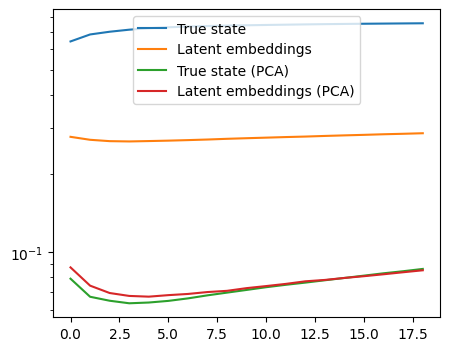

In [52]:
fnn_losses_true   = []
fnn_losses_latent = []
fnn_losses_true_pca   = []
fnn_losses_latent_pca = []
for k in range(1, 20):
    fnn_loss_true   = loss_false(X_true_sub, k=k, normalize=True).item()
    fnn_loss_latent = loss_false(X_latent_sub, k=k, normalize=True).item()
    fnn_loss_true_pca   = loss_false(X_true_pca, k=k, normalize=True).item()
    fnn_loss_latent_pca = loss_false(X_latent_pca, k=k, normalize=True).item()
    fnn_losses_true.append(fnn_loss_true)
    fnn_losses_latent.append(fnn_loss_latent)
    fnn_losses_true_pca.append(fnn_loss_true_pca)
    fnn_losses_latent_pca.append(fnn_loss_latent_pca)

fig, ax = plt.subplots(figsize=(5, 4))
plt.plot(fnn_losses_true, label='True state')
plt.plot(fnn_losses_latent, label='Latent embeddings')
plt.plot(fnn_losses_true_pca, label='True state (PCA)')
plt.plot(fnn_losses_latent_pca, label='Latent embeddings (PCA)')
plt.yscale('log')
plt.legend()
plt.show()


## Amplification Loss

Computes the noise-amplification loss via `loss_amplification` in `JacobianODE.fnn`.

For each point in the embedding, the $K$ nearest neighbors are found in embedding space.  
The amplification metric is the ratio of how much those neighbors diverge in **data space** over the next $T$ steps to how close they were in **embedding space**:

$$\sigma = \left\langle \frac{E_k(T)}{\varepsilon_k} \right\rangle, \quad E_k(T) = \frac{1}{K}\sum_{j\in\mathcal{N}_k} \bigl\|\mathbf{x}_{t+T}^{(j)} - \bar{\mathbf{x}}_{t+T}\bigr\|^2, \quad \varepsilon_k = \frac{1}{K(K-1)}\sum_{i\ne j\in\mathcal{N}_k}\|\mathbf{z}^{(i)}-\mathbf{z}^{(j)}\|^2$$

Lower $\sigma$ means nearby points in the embedding stay close in the future — a sign of a well-ordered, low-noise embedding.

We compare:
- **True state** — `test_trajs_full` $(B, T, 3)$, neighbors found and divergence measured in observation space
- **Latent embeddings** — `latent_traj_full` $(B, T, D_\text{latent})$, neighbors found and divergence measured in latent space

Amplification loss — True state (3-D): 0.000311
Amplification loss — Latent:           0.000305


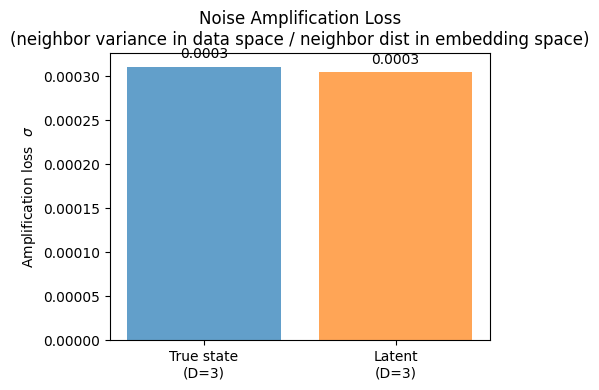

In [53]:
from JacobianODE.fnn import loss_amplification

# ---------------------------------------------------------------
# Subsample trajectories; use test_trajs_full (3-D) as "true" reference.
# ---------------------------------------------------------------
N_TRAJS     = 64
N_NEIGHBORS = 2
MAX_T       = 5
rng_amp = np.random.default_rng(42)

B_amp   = test_trajs_full.shape[0]
idx_amp = rng_amp.choice(B_amp, min(N_TRAJS, B_amp), replace=False)

X_true_ts   = test_trajs_full[torch.from_numpy(idx_amp)].float()       # (N_TRAJS, T, 3)
X_latent_ts = latent_traj_full[torch.from_numpy(idx_amp)].float()      # (N_TRAJS, T, D_latent)

with torch.no_grad():
    amp_loss_true   = loss_amplification(X_true_ts,   X_true_ts, n_neighbors=N_NEIGHBORS, max_T=MAX_T, normalize=True).item()
    amp_loss_latent = loss_amplification(X_latent_ts, X_true_ts, n_neighbors=N_NEIGHBORS, max_T=MAX_T, normalize=True).item()

print(f"Amplification loss — True state (3-D): {amp_loss_true:.6f}")
print(f"Amplification loss — Latent:           {amp_loss_latent:.6f}")

# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------
D_latent = X_latent_ts.shape[-1]
labels = [f'True state\n(D=3)', f'Latent\n(D={D_latent})']
values = [amp_loss_true, amp_loss_latent]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, values, color=['C0', 'C1'], alpha=0.7)
ax.set_ylabel('Amplification loss  $\\sigma$')
ax.set_title('Noise Amplification Loss\n(neighbor variance in data space / neighbor dist in embedding space)')
for bar, val in zip(bars, values):
    ax.annotate(f'{val:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom')
plt.tight_layout()
plt.show()


In [54]:
N_NEIGHBORS_VALS = np.arange(2, 21)
MAX_T_VALS = np.arange(2, 21)

heatmap_diff = np.zeros((len(MAX_T_VALS), len(N_NEIGHBORS_VALS)))

with torch.no_grad():
    for i, max_t in enumerate(MAX_T_VALS):
        for j, n_nbrs in enumerate(N_NEIGHBORS_VALS):
            amp_loss_true = loss_amplification(
                X_true_ts, X_true_ts, n_neighbors=int(n_nbrs), max_T=int(max_t), normalize=True
            ).item()
            amp_loss_latent = loss_amplification(
                X_latent_ts, X_true_ts, n_neighbors=int(n_nbrs), max_T=int(max_t), normalize=True
            ).item()
            heatmap_diff[i, j] = amp_loss_latent - amp_loss_true

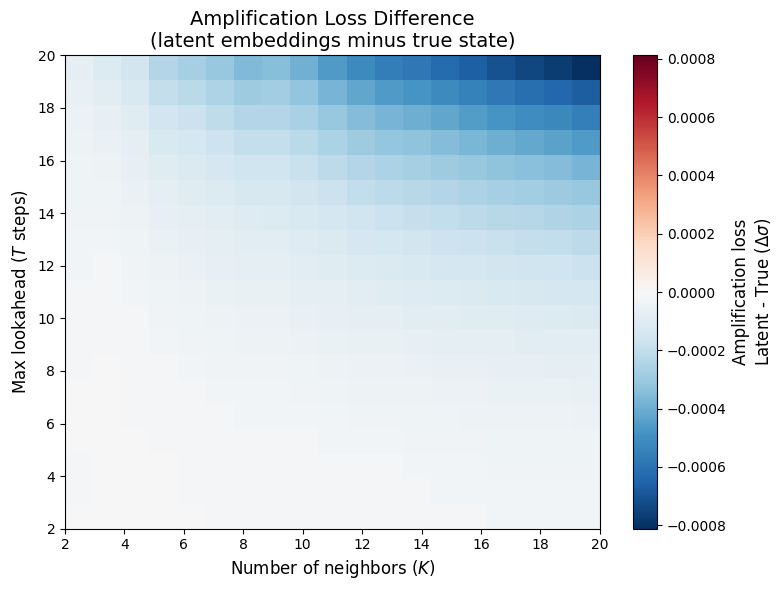

In [55]:
fig, ax = plt.subplots(figsize=(8, 6))

# Find the max abs value for symmetric color scaling around zero
abs_max = np.abs(heatmap_diff).max()

im = ax.imshow(
    heatmap_diff, 
    aspect='auto', 
    origin='lower', 
    extent=[N_NEIGHBORS_VALS[0], N_NEIGHBORS_VALS[-1], MAX_T_VALS[0], MAX_T_VALS[-1]],
    cmap='RdBu_r',
    vmin=-abs_max,
    vmax=abs_max
)
cbar = plt.colorbar(im, ax=ax)
# Use a raw string to avoid invalid escape sequence warning for "\D"
cbar.set_label("Amplification loss\nLatent " + r"- True ($\Delta \sigma$)", fontsize=12)

ax.set_xlabel(r"Number of neighbors ($K$)", fontsize=12)
ax.set_ylabel(r"Max lookahead ($T$ steps)", fontsize=12)
ax.set_title("Amplification Loss Difference\n(latent" + r" embeddings minus true state)", fontsize=14)
plt.tight_layout()
plt.show()

In [76]:
lit_model.loop_closure_weight

0.001

In [89]:

# ── True Lyapunov exponents from analytical Lorenz Jacobians ──────────────────
# Compute the analytical Lorenz Jacobian at every timestep of every
# full-system test trajectory (denormalising first), then run the same
# QR-decomposition pipeline used for the estimated Jacobians.

sigma_t = torch.as_tensor(sigma, dtype=torch.float32)
mu_t    = torch.as_tensor(mu,    dtype=torch.float32)

B, T, D = test_trajs_full.shape
true_jacs = torch.zeros(B, T, D, D, dtype=torch.float32)

for b in range(B):
    for t in range(T):
        x_raw = test_trajs_full[b, t] * sigma_t + mu_t   # denormalise (3-D)
        true_jacs[b, t] = lorenz_jacobian(x_raw)

with torch.no_grad():
    lyaps_true = lit_model.to(device).compute_lyapunov_exponents(
        true_jacs.to(device), dt
    )
lyaps_true = lyaps_true.cpu()

# ── Comparison ────────────────────────────────────────────────────────────────
true_mean = lyaps_true.mean(0).numpy()
est_mean  = lyaps_full.mean(0).numpy()
# err       = lyaps_full - lyaps_true

print("True Lyapunov exponents  (analytical Lorenz Jacobians, full 3-D test trajs)")
print(f"  per trajectory : {lyaps_true.numpy()}")
print(f"  mean           : {true_mean}")
print()
print("Estimated Lyapunov exponents  (learned latent Jacobians)")
print(f"  per trajectory : {lyaps_full.numpy()}")
print(f"  mean           : {est_mean}")
print()
print(f"Known theoretical values : {TRUE_LYAPUNOV}")
# print()
# print("Error  (estimated − true)")
# print(f"  per trajectory : {err.numpy()}")
# print(f"  mean abs error : {err.abs().mean(0).numpy()}")



True Lyapunov exponents  (analytical Lorenz Jacobians, full 3-D test trajs)
  per trajectory : [[  0.40258616  -0.14989482 -13.919351  ]
 [  0.3957496   -0.2226313  -13.839791  ]
 [  0.3562274   -0.14229797 -13.880589  ]]
  mean           : [  0.3848544   -0.17160803 -13.87991   ]

Estimated Lyapunov exponents  (learned latent Jacobians)
  per trajectory : [[  0.1867801   -1.0606143  -14.283893  ]
 [  0.12565805  -1.0447901  -14.337072  ]
 [  0.02199301  -0.9732685  -14.297143  ]]
  mean           : [  0.11147705  -1.0262243  -14.306035  ]

Known theoretical values : [0.91, 0.0, -14.57]
